# 04 - Shallow baselines and BiLSTM

Establishes the classical baselines and trains the BiLSTM. The ablation is the
point: each configuration adds one block of features, so the gain can be attributed.

| Config | Input | Features |
|---|---|---|
| B1 | raw keypoints + RF | 387 |
| B2 | corrected keypoints + RF | 387 |
| B3 | corrected + Δz + RF | 459 |
| B4 | full feature set + RF | 576 |
| B5 | full feature set + HistGradientBoosting | 576 |
| M1 | full feature set + BiLSTM | 64 per frame, 64-frame windows |

The shallow models consume window statistics, which is why their feature count is
much larger than the 64 per-frame features the sequence models see.

**Input:** `CalMS21_task1`, video 13638642.

Read §A1 and §A3 at the end before drawing conclusions from the middle sections:
the honest multi-video evaluation reverses two of the results that the single-video
sections suggest.

## §1 Imports and constants

In [1]:
import sys, warnings, time, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

# Make sure src/ is on the path
ROOT = Path("..")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore")

# Experiment constants
LAB         = "CalMS21_task1"
VIDEO_ID    = "13638642"
DATASET_DIR = ROOT / "dataset" / "MABe-mouse-behavior-detection"
FEATURES_H5 = ROOT / "dataset" / "features" / f"{LAB}_{VIDEO_ID}_features.h5"
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
BATCH_SIZE = 32

# ── Reproducibilidad completa (#14) ──────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"Features HDF5: {FEATURES_H5} — existe: {FEATURES_H5.exists()}")

Device: cpu
PyTorch: 2.11.0+cpu
Features HDF5: ..\dataset\features\CalMS21_task1_13638642_features.h5 — existe: True


## §2 Load tracking and build features

Four variants, one per ablation step:

- `X_raw`: raw coordinates, no Δz, no relational features (B1)
- `X_corr`: corrected, no Δz, no relational (B2)
- `X_dz`: corrected plus Δz (B3)
- `X_full`: corrected plus Δz plus relational, 64 per frame (B4, B5, M1)

In [2]:
from src.data.loader import load_tracking, load_tracking_wide, load_annotations
from src.data.features import (
    extract_features, window_statistics, WINDOW_SIZE, STRIDE
)
from src.data.dataset import MouseBehaviorDataset, LabelEncoder, TARGET_CLASSES, train_val_test_split
from src.skeleton.keypoint_smoother import smooth_video

# Cargar tracking bruto y anotaciones
tracking_raw = load_tracking(VIDEO_ID, LAB)
annotations = load_annotations(VIDEO_ID, LAB)

print(f"Frames raw:       {tracking_raw['video_frame'].nunique():,}")
print(f"Behaviours:       {sorted(annotations['action'].unique().tolist())}")


Frames raw:       6,330
Comportamientos:  ['approach', 'mount', 'sniffbody', 'sniffface', 'sniffgenital']


In [3]:
# Fit the skeleton to the video.
# build_skeleton() sets up the keypoints and edges; fit_skeleton() estimates L_ref
# and L_std from the data.
from src.skeleton.mouse_skeleton import build_skeleton, fit_skeleton

skeleton = build_skeleton(LAB)
fit_skeleton(skeleton, tracking_raw)
print(f"L_body_median_px: {skeleton.L_body_median_px:.1f} px")
print(f"Keypoints ({len(skeleton.keypoints)}): {skeleton.keypoints}")
print(f"Aristas ({len(skeleton.edges)}): {[(e.src, e.dst) for e in skeleton.edges]}")


L_body_median_px: 175.5 px
Keypoints (7): ['nose', 'neck', 'ear_left', 'ear_right', 'hip_left', 'hip_right', 'tail_base']
Aristas (7): [('nose', 'neck'), ('neck', 'ear_left'), ('neck', 'ear_right'), ('neck', 'hip_left'), ('neck', 'hip_right'), ('hip_left', 'tail_base'), ('hip_right', 'tail_base')]


In [4]:
# MouseSkeleton correction, v2b
t0 = time.time()
tracking_corr, report = smooth_video(tracking_raw, LAB, skeleton=skeleton, auto_edge_lambdas=True)
print(f"Correction finished in {time.time()-t0:.1f}s")
print(f"  Frames outlier: {report['n_outlier_frames']} / {report['n_total_frames']} "
      f"({100*report['n_outlier_frames']/report['n_total_frames']:.1f}%)")

  mouse 1:   0%|          | 0/110 [00:00<?, ?win/s]

  mouse 2:   0%|          | 0/88 [00:00<?, ?win/s]

Corrección completada en 75.1s
  Frames outlier: 9044 / 11526 (78.5%)


In [5]:
# ── B1: raw features, uncorrected, no dz, no relational ─────────────────
print("Extracting B1 (raw, no dz, no relational)...")
res_raw = extract_features(
    tracking_raw, skeleton, annotations,
    include_dz=False, include_relational=False
)
# mouse_id=1 is the reference, being the main active mouse
mouse_id_ref = sorted(res_raw.keys())[0]
X_raw_seq = res_raw[mouse_id_ref]["X"]
y_raw_str = res_raw[mouse_id_ref]["y"]
fn_raw    = res_raw[mouse_id_ref]["feature_names"]
print(f"  Windows: {X_raw_seq.shape[0]}, features: {X_raw_seq.shape[2]}")

Extrayendo B1 (raw, sin Δz, sin relacional)...
  Ventanas: 179, features: 43


In [6]:
# ── B2: corrected, no dz, no relational ─────────────────────────────────
print("Extracting B2 (corrected, no dz, no relational)...")
res_corr = extract_features(
    tracking_corr, skeleton, annotations,
    include_dz=False, include_relational=False
)
X_corr_seq = res_corr[mouse_id_ref]["X"]
y_corr_str = res_corr[mouse_id_ref]["y"]
fn_corr    = res_corr[mouse_id_ref]["feature_names"]
print(f"  Windows: {X_corr_seq.shape[0]}, features: {X_corr_seq.shape[2]}")

Extrayendo B2 (corrected, sin Δz, sin relacional)...
  Ventanas: 179, features: 43


In [7]:
# ── B3: corrected plus dz, no relational ────────────────────────────────
print("Extracting B3 (corrected + dz, no relational)...")
res_dz = extract_features(
    tracking_corr, skeleton, annotations,
    include_dz=True, include_relational=False
)
X_dz_seq = res_dz[mouse_id_ref]["X"]
y_dz_str = res_dz[mouse_id_ref]["y"]
fn_dz    = res_dz[mouse_id_ref]["feature_names"]
print(f"  Windows: {X_dz_seq.shape[0]}, features: {X_dz_seq.shape[2]}")

Extrayendo B3 (corrected + Δz, sin relacional)...
  Ventanas: 179, features: 51


In [8]:
# ── B4/M1: 50 features completas ─────────────────────────────────────────
print("Extrayendo B4/M1 (corrected + Δz + relacional, 50 features)...")
res_full = extract_features(
    tracking_corr, skeleton, annotations,
    include_dz=True, include_relational=True
)
X_full_seq = res_full[mouse_id_ref]["X"]
y_full_str = res_full[mouse_id_ref]["y"]
fn_full    = res_full[mouse_id_ref]["feature_names"]
print(f"  Windows: {X_full_seq.shape[0]}, features: {X_full_seq.shape[2]}")
print(f"  Features: {fn_full[:5]} ... {fn_full[-3:]}")

Extrayendo B4/M1 (corrected + Δz + relacional, 50 features)...
  Ventanas: 179, features: 64
  Features: ['centroid_x', 'centroid_y', 'centroid_vx', 'centroid_vy', 'centroid_speed'] ... ['facing_b', 'speed_relative', 'dz_centroid_diff']


In [9]:
# ── Actual dimensionality of each feature set ───────────────────────────────
# Named explicitly to avoid confusing "50 full features" with the real count,
# which varies with the version of extract_features.
FEATURE_SETS = {
    "raw":  X_raw_seq.shape[2],   # B1: raw keypoints, x and y per keypoint
    "corr": X_corr_seq.shape[2],  # B2: keypoints corregidos MouseSkeleton
    "dz":   X_dz_seq.shape[2],    # B3: plus the implicit dz
    "full": X_full_seq.shape[2],  # B4: plus the inter-mouse relational features
}
print("Sequential dimensionality (features per frame):", FEATURE_SETS)

# The flat features (window_statistics) multiply this by 6 statistics per feature
# (mean, std, min, max, skew, kurt) → dim_flat = full * 6
_expected_flat = FEATURE_SETS["full"] * 6  # the theoretical value, no extra statistics

Dimensión secuencial (features por frame): {'raw': 43, 'corr': 43, 'dz': 51, 'full': 64}


## §2b Multi-video feature extraction

Loads the five most densely annotated `CalMS21_task1` videos, which widens the
training set and makes leave-one-video-out possible in §8b.

Flags: `N_VIDEOS`, `USE_CACHED_MULTI` to skip recomputation, and `SKIP_SMOOTHING`
for a fast pass without the skeleton correction.

In [10]:
# ── Multi-video feature extraction ──────────────────────────────────────────
import time as _time
from src.data.loader import iter_lab_videos, load_lab_annotations
from src.skeleton.config import skeleton_smooth_kwargs  # A1: unified correction params

N_VIDEOS         = 5
USE_CACHED_MULTI = True   # set False to recompute from scratch
SKIP_SMOOTHING   = False  # True is faster, but skips the skeletal correction

CACHE_PATH = ROOT / 'dataset' / 'features' / f'{LAB}_multi_{N_VIDEOS}_features.npz'

if USE_CACHED_MULTI and CACHE_PATH.exists():
    _cache        = np.load(CACHE_PATH, allow_pickle=True)
    X_multi       = _cache['X']
    y_multi       = _cache['y']
    video_ids_arr = _cache['video_ids']
    multi_classes = list(_cache['classes'])
    enc_multi     = LabelEncoder(classes=multi_classes)
    print(f'✔ Cache cargada: {CACHE_PATH}')
    print(f'  X_multi: {X_multi.shape}, classes: {multi_classes}')
else:
    # 1. Take the N_VIDEOS videos with the most behaviour frames
    print(f'Selecting the top {N_VIDEOS} videos by annotation density...')
    _all_ann = load_lab_annotations(LAB)
    _counts_vid = (
        _all_ann[~_all_ann['action'].isin(['background', 'other', 'none', 'None'])]
        .groupby('video_id')['duration_frames'].sum()
        .sort_values(ascending=False)
    )
    top_ids = list(_counts_vid.head(N_VIDEOS).index.astype(str))
    if VIDEO_ID not in top_ids:
        top_ids[-1] = VIDEO_ID
    print(f'  Videos selected: {top_ids}')

    # 2. Extract features per video
    X_parts, y_parts, vid_parts = [], [], []
    for vid in top_ids:
        t0 = _time.time()
        print(f'  [{vid}] cargando... ', end='', flush=True)
        tr_raw_v = load_tracking(vid, LAB)
        ann_v    = load_annotations(vid, LAB)
        skel_v   = build_skeleton(LAB)
        fit_skeleton(skel_v, tr_raw_v)
        tr_v = tr_raw_v if SKIP_SMOOTHING else \
               smooth_video(tr_raw_v, LAB, skeleton=skel_v, **skeleton_smooth_kwargs())[0]
        res_v   = extract_features(tr_v, skel_v, ann_v, include_dz=True, include_relational=True)
        m_ref_v = sorted(res_v.keys())[0]
        X_parts.append(res_v[m_ref_v]['X'])
        y_parts.append(res_v[m_ref_v]['y'])
        vid_parts.append(np.full(len(res_v[m_ref_v]['y']), vid, dtype=object))
        print(f'OK ({len(res_v[m_ref_v]["y"])} windows, {_time.time()-t0:.0f}s)')

    # 3. Multi-video encoder, over the union of the classes
    _all_labels = np.concatenate(y_parts)
    multi_classes = sorted(set(_all_labels) - {'background', 'other', 'none', 'None'})
    enc_multi = LabelEncoder(classes=multi_classes)
    X_parts_f, y_parts_f, vid_parts_f = [], [], []
    for Xv, yv, vidv in zip(X_parts, y_parts, vid_parts):
        yi   = enc_multi.encode(yv)
        mask = yi >= 0
        X_parts_f.append(Xv[mask])
        y_parts_f.append(yi[mask])
        vid_parts_f.append(vidv[mask])
    X_multi       = np.concatenate(X_parts_f, axis=0)
    y_multi       = np.concatenate(y_parts_f, axis=0)
    video_ids_arr = np.concatenate(vid_parts_f, axis=0)

    # 4. Guardar cache
    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    np.savez(CACHE_PATH, X=X_multi, y=y_multi,
             video_ids=video_ids_arr, classes=np.array(multi_classes))
    print(f'✔ Cache guardada: {CACHE_PATH}')

print(f'\nMulti-video dataset: {X_multi.shape[0]} windows '
      f'({X_multi.shape[0]/max(len(y_full_str),1):.1f}x the single video)')
print(f'Classes ({len(multi_classes)}): {multi_classes}')
_cls_u, _cls_c = np.unique(y_multi, return_counts=True)
for ci, cnt in zip(_cls_u, _cls_c):
    print(f'  {multi_classes[ci]:15s}: {cnt:4d} windows')


✔ Cache cargada: ..\dataset\features\CalMS21_task1_multi_5_features.npz
  X_multi: (1781, 64, 64), clases: [np.str_('approach'), np.str_('intromit'), np.str_('mount'), np.str_('sniff'), np.str_('sniffbody'), np.str_('sniffface'), np.str_('sniffgenital')]

Dataset multi-vídeo: 1781 ventanas (×9.9x vídeo único)
Clases (7): [np.str_('approach'), np.str_('intromit'), np.str_('mount'), np.str_('sniff'), np.str_('sniffbody'), np.str_('sniffface'), np.str_('sniffgenital')]
  approach       :   16 ventanas
  intromit       :  125 ventanas
  mount          :  505 ventanas
  sniff          :  935 ventanas
  sniffbody      :   34 ventanas
  sniffface      :   15 ventanas
  sniffgenital   :  151 ventanas


## §3 Label encoding and splits

In [11]:
# Build the encoder from the video's ACTUAL labels, not the global TARGET_CLASSES
# CalMS21_task1 usa: approach, mount, sniffbody, sniffface, sniffgenital
# which do not match TARGET_CLASSES, so only approach and mount would survive
actual_classes = sorted([
    a for a in annotations['action'].unique()
    if a not in ("background", "other", "none", "None")
])
print(f"Classes in this video: {actual_classes}")

enc = LabelEncoder(classes=actual_classes)

def encode_and_filter(X_seq, y_str):
    """Encode the labels and filter out background (-1)."""
    y_int = enc.encode(y_str)
    mask  = y_int >= 0
    return X_seq[mask], y_int[mask]

X_raw,  y_raw  = encode_and_filter(X_raw_seq,  y_raw_str)
X_corr, y_corr = encode_and_filter(X_corr_seq, y_corr_str)
X_dz,   y_dz   = encode_and_filter(X_dz_seq,   y_dz_str)
X_full, y_full = encode_and_filter(X_full_seq,  y_full_str)

for name, X, y in [("raw", X_raw, y_raw), ("corr", X_corr, y_corr),
                    ("dz",  X_dz,  y_dz),  ("full", X_full, y_full)]:
    classes, counts = np.unique(y, return_counts=True)
    print(f"{name:6s}: {len(y):4d} windows, "
          f"classes={[f'{enc.classes[c]}:{n}' for c,n in zip(classes,counts)]}")


Clases en el vídeo: ['approach', 'mount', 'sniffbody', 'sniffface', 'sniffgenital']
raw   :  103 ventanas, clases=['approach:16', 'mount:21', 'sniffbody:34', 'sniffface:15', 'sniffgenital:17']
corr  :  103 ventanas, clases=['approach:16', 'mount:21', 'sniffbody:34', 'sniffface:15', 'sniffgenital:17']
dz    :  103 ventanas, clases=['approach:16', 'mount:21', 'sniffbody:34', 'sniffface:15', 'sniffgenital:17']
full  :  103 ventanas, clases=['approach:16', 'mount:21', 'sniffbody:34', 'sniffface:15', 'sniffgenital:17']


## §4 Classical baselines

> **Leaky protocol. Optimistic, not the headline.** The cross-validation here uses `StratifiedKFold` over windows that overlap by 75% (window 64, stride 16), so near-identical frames land in both train and validation. The honest number is in **§A1**: leave-one-video-out over 20 videos with the official `f1_event`, where the random forest drops to about 0.53.

Kept as an illustration of the classical pipeline and of the ablation shape, not as
a result.

In [12]:
import importlib
import src.models.baseline as _baseline_mod
importlib.reload(_baseline_mod)

from src.data.features import window_statistics
from src.models.baseline import RandomForestBaseline, SVMBaseline, GradientBoostingBaseline
from src.evaluate import classification_report_df, metrics_summary

def to_flat(X_seq, feature_names):
    """Flatten (N, 64, F) windows to (N, 6*F) using per-window statistics."""
    X_flat, stat_names = window_statistics(X_seq, feature_names)
    return X_flat, stat_names

# Preparar datasets planos
X_raw_flat,  fn_raw_flat  = to_flat(X_raw,  fn_raw)
X_corr_flat, fn_corr_flat = to_flat(X_corr, fn_corr)
X_dz_flat,   fn_dz_flat   = to_flat(X_dz,   fn_dz)
X_full_flat, fn_full_flat  = to_flat(X_full,  fn_full)

print(f"Forma vectores planos: raw={X_raw_flat.shape}, full={X_full_flat.shape}")


Forma vectores planos: raw=(103, 387), full=(103, 576)


In [13]:

# Full ablation, B1 to B5, with a random forest and HistGBC.
# Stratified CV, StratifiedKFold(shuffle=True), keeps the class distribution per fold.
# TimeSeriesSplit produces degenerate folds here, because the behaviours are ordered in
# time and the early classes occupy the first frames, giving single-class folds and NaN
# on sklearn 1.8 and later, where error_score defaults to nan.
# The overlap leakage at stride=16 is handled instead by the purge in the hold-out split.

ablation_configs = {
    "B1_raw_rf":    (X_raw_flat,  y_raw),
    "B2_corr_rf":   (X_corr_flat, y_corr),
    "B3_dz_rf":     (X_dz_flat,   y_dz),
    "B4_full_rf":   (X_full_flat, y_full),
}

ablation_results = {}
for name, (X_ab, y_ab) in ablation_configs.items():
    print(f"  {name}... ", end="", flush=True)
    clf = RandomForestBaseline(n_estimators=300, seed=SEED)
    n_splits = min(5, int(np.bincount(y_ab).min())) if len(y_ab) > 10 else 2
    n_splits = max(n_splits, 2)
    cv_res = clf.cross_validate_temporal(X_ab, y_ab, n_splits=n_splits, seed=SEED)
    ablation_results[name] = {
        "f1_macro": f"{np.mean(cv_res['test_f1_macro']):.3f} ± {np.std(cv_res['test_f1_macro']):.3f}",
        "accuracy": f"{np.mean(cv_res['test_accuracy']):.3f} ± {np.std(cv_res['test_accuracy']):.3f}",
        "n_features": X_ab.shape[1],
        "n_windows": len(y_ab),
    }
    print(f"F1-macro={np.mean(cv_res['test_f1_macro']):.3f}")

# B5: HistGradientBoosting over the full feature set
print("  B5_full_gb... ", end="", flush=True)
gb = GradientBoostingBaseline()
n_splits_gb = min(5, int(np.bincount(y_full).min())) if len(y_full) > 10 else 2
n_splits_gb = max(n_splits_gb, 2)
cv_gb = gb.cross_validate_temporal(X_full_flat, y_full, n_splits=n_splits_gb, seed=SEED)
ablation_results["B5_full_gb"] = {
    "f1_macro": f"{np.mean(cv_gb['test_f1_macro']):.3f} ± {np.std(cv_gb['test_f1_macro']):.3f}",
    "accuracy": f"{np.mean(cv_gb['test_accuracy']):.3f} ± {np.std(cv_gb['test_accuracy']):.3f}",
    "n_features": X_full_flat.shape[1],
    "n_windows": len(y_full),
}
print(f"F1-macro={np.mean(cv_gb['test_f1_macro']):.3f}")

df_ablation = pd.DataFrame(ablation_results).T
print("\n=== Ablation table (RF + HistGBC, StratifiedKFold CV) ===")
print(df_ablation.to_string())


  B1_raw_rf... F1-macro=0.449
  B2_corr_rf... F1-macro=0.504
  B3_dz_rf... F1-macro=0.546
  B4_full_rf... F1-macro=0.611
  B5_full_gb... F1-macro=0.613

=== Tabla de ablación (RF + HistGBC, StratifiedKFold CV) ===
                 f1_macro       accuracy n_features n_windows
B1_raw_rf   0.449 ± 0.040  0.564 ± 0.046        387       103
B2_corr_rf  0.504 ± 0.027  0.554 ± 0.053        387       103
B3_dz_rf    0.546 ± 0.080  0.621 ± 0.068        459       103
B4_full_rf  0.611 ± 0.087  0.689 ± 0.092        576       103
B5_full_gb  0.613 ± 0.037  0.660 ± 0.026        576       103


In [14]:

# Compare the models (RF, SVM, GB) over the full feature set B4.
# StratifiedKFold, the same protocol as the ablation.
model_comparison = {}
for model_name, clf_class in [
    ("RandomForest",      RandomForestBaseline),
    ("SVM",               SVMBaseline),
    ("GradientBoosting",  GradientBoostingBaseline),
]:
    print(f"  {model_name}... ", end="", flush=True)
    clf = clf_class()
    n_splits = min(5, int(np.bincount(y_full).min())) if len(y_full) > 10 else 2
    n_splits = max(n_splits, 2)
    cv_res = clf.cross_validate_temporal(X_full_flat, y_full, n_splits=n_splits, seed=SEED)
    model_comparison[model_name] = {
        "f1_macro": f"{np.mean(cv_res['test_f1_macro']):.3f} ± {np.std(cv_res['test_f1_macro']):.3f}",
        "accuracy": f"{np.mean(cv_res['test_accuracy']):.3f}",
    }
    print(f"F1-macro={np.mean(cv_res['test_f1_macro']):.3f}")

df_models = pd.DataFrame(model_comparison).T
print(f"\n=== Model comparison ({FEATURE_SETS['full']} seq features -> flat, B4, StratifiedKFold) ===")
print(df_models.to_string())


  RandomForest... F1-macro=0.611
  SVM... F1-macro=0.437
  GradientBoosting... F1-macro=0.613

=== Comparativa de modelos (64 features seq → flat, B4, StratifiedKFold) ===
                       f1_macro accuracy
RandomForest      0.611 ± 0.087    0.689
SVM               0.437 ± 0.099    0.562
GradientBoosting  0.613 ± 0.037    0.660


## §5 Feature importance

In [15]:
# Train the random forest on the temporal hold-out split, to get importances.
# A 70/15/15 temporal split: no stratification and no shuffling of windows.
# The windows are in temporal order and the test set is the final 15%.
# No test frame appears in training; the stride provides an implicit purge.

N_flat = len(y_full)
n_test_rf = max(1, int(0.15 * N_flat))
n_val_rf  = max(1, int(0.15 * N_flat))

X_tr = X_full_flat[:N_flat - n_val_rf - n_test_rf]
X_te = X_full_flat[N_flat - n_test_rf:]
y_tr = y_full[:N_flat - n_val_rf - n_test_rf]
y_te = y_full[N_flat - n_test_rf:]

print(f"RF split temporal — train: {len(y_tr)}, val: {n_val_rf}, test: {len(y_te)}")

rf = RandomForestBaseline(n_estimators=300, seed=SEED)
rf.fit(X_tr, y_tr)
print(f"RF accuracy (hold-out temporal): {rf.score(X_te, y_te):.3f}")
print(f"RF F1-macro  (hold-out temporal): {rf.f1_macro(X_te, y_te):.3f}")


RF split temporal — train: 73, val: 15, test: 15
RF accuracy (hold-out temporal): 0.667
RF F1-macro  (hold-out temporal): 0.517


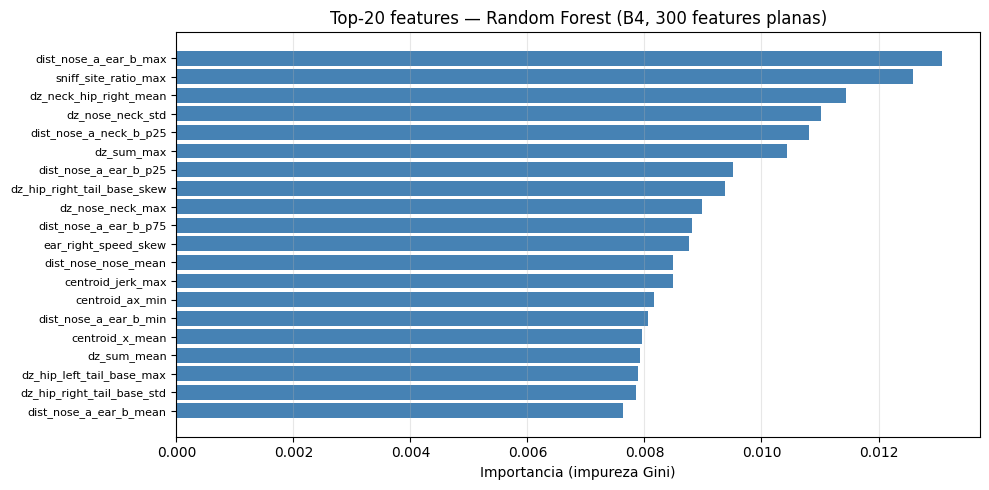

Top-5 features: ['dist_nose_a_ear_b_max', 'sniff_site_ratio_max', 'dz_neck_hip_right_mean', 'dz_nose_neck_std', 'dist_nose_a_neck_b_p25']


In [16]:
# The 20 most important features
importances = rf.feature_importances_
if importances is not None:
    idx_top = np.argsort(importances)[::-1][:20]
    top_names = [fn_full_flat[i] for i in idx_top]
    top_vals  = importances[idx_top]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(range(20), top_vals[::-1], color="steelblue")
    ax.set_yticks(range(20))
    ax.set_yticklabels(top_names[::-1], fontsize=8)
    ax.set_xlabel("Importancia (impureza Gini)")
    ax.set_title("Top-20 features — Random Forest (B4, 300 features planas)")
    ax.grid(True, alpha=0.3, axis="x")
    fig.tight_layout()
    plt.show()
    print("Top-5 features:", top_names[:5])
else:
    print("Importances not available for this model")

## §6 Confusion matrices: B1 against B4

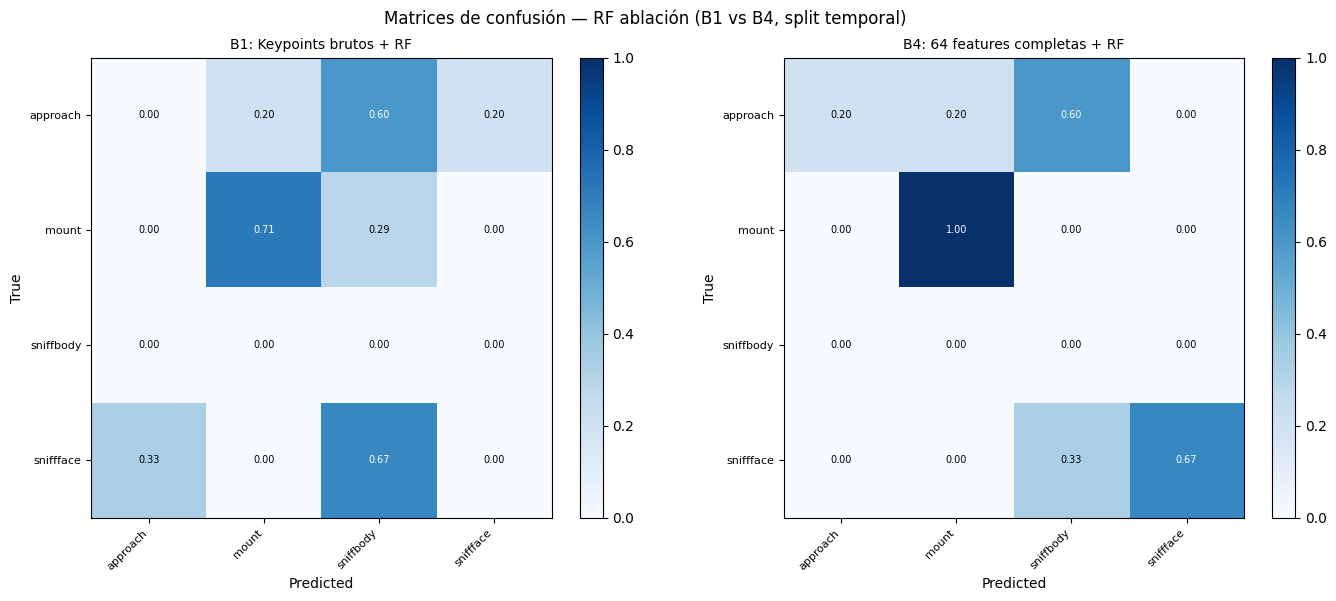

In [17]:
from src.evaluate import plot_confusion_matrix, evaluate_baseline

# B1 (raw), on a temporal split consistent with the one used above
N_raw = len(y_raw)
n_te_raw = max(1, int(0.15 * N_raw))
X_tr_raw = X_raw_flat[:N_raw - 2 * n_te_raw]
X_te_raw = X_raw_flat[N_raw - n_te_raw:]
y_tr_raw = y_raw[:N_raw - 2 * n_te_raw]
y_te_raw = y_raw[N_raw - n_te_raw:]

rf_b1 = RandomForestBaseline(n_estimators=300, seed=SEED)
rf_b1.fit(X_tr_raw, y_tr_raw)
_, y_pred_b1, _ = evaluate_baseline(rf_b1, X_te_raw, y_te_raw)

# B4 (full)
_, y_pred_b4, _ = evaluate_baseline(rf, X_te, y_te)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
class_names = enc.classes

for ax_idx, (y_true_cm, y_pred_cm, title) in enumerate([
    (y_te_raw, y_pred_b1, "B1: Keypoints brutos + RF"),
    (y_te,     y_pred_b4, f"B4: {FEATURE_SETS['full']} features completas + RF"),
]):
    from sklearn.metrics import confusion_matrix
    labels_present = sorted(np.unique(np.concatenate([y_true_cm, y_pred_cm])).tolist())
    names_present  = [class_names[i] for i in labels_present]
    cm = confusion_matrix(y_true_cm, y_pred_cm, labels=labels_present)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm.astype(float), row_sums, where=row_sums != 0)
    ax = axes[ax_idx]
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(names_present)))
    ax.set_yticks(range(len(names_present)))
    ax.set_xticklabels(names_present, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(names_present, fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    thresh = 0.5
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            ax.text(j, i, f"{cm_norm[i,j]:.2f}",
                   ha="center", va="center", fontsize=7,
                   color="white" if cm_norm[i,j] > thresh else "black")
    fig.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle("Confusion matrices - RF ablation (B1 vs B4, temporal split)", fontsize=12)
fig.tight_layout()
plt.show()


## §7 BiLSTM

> **Single video, high variance. Illustrative only.** These sections train and evaluate on **one** video with a temporal split, leaving 13 to 30 test windows and some classes with no support at all. The F1 is unstable and **not comparable** across models. The generalisation verdict is in **§8b** and **§A1**.

Trains M1 on the full feature set, as sequences of shape (N, 64, 64).

In [18]:
from src.data.dataset import MouseBehaviorDataset, train_val_test_split_temporal
from src.models.rnn import BehaviorLSTM, FocalLoss
from src.train import fit
from src.evaluate import evaluate_model, plot_training_curves

# Build the PyTorch dataset from the full (N, W, F) sequences
ds_full = MouseBehaviorDataset(
    X_full, y_full,
    feature_names=fn_full,
    include_background=False,
)
print(f"Dataset: {len(ds_full)} windows, {ds_full.n_features} features ({FEATURE_SETS['full']} seq), {ds_full.window_size} frames")
print(f"Class distribution: {ds_full.class_counts()}")


Dataset: 103 ventanas, 64 features (64 seq), 64 frames
Distribución de clases: {0: 16, 1: 21, 2: 34, 3: 15, 4: 17}


In [19]:
import math

# A 70/15/15 temporal split, with a purge at each boundary.
# purge_windows = ceil(WINDOW_SIZE / STRIDE) is the minimum number of windows to drop
# at each boundary so that no training frame shares data with validation or test,
# which removes the 75% overlap leakage.
# With WINDOW_SIZE=64 and STRIDE=16 that gives purge_windows=4, not 64.
#
# NOTE: the existing checkpoints were trained on a random split. For a fully honest
# evaluation, set FORCE_RETRAIN_M1 = True.
torch.manual_seed(SEED)
np.random.seed(SEED)

purge_windows = math.ceil(WINDOW_SIZE / STRIDE)
train_ds, val_ds, test_ds = train_val_test_split_temporal(
    ds_full, val_frac=0.15, test_frac=0.15, purge=purge_windows
)
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
print(f"Purging {purge_windows} windows per boundary (WINDOW_SIZE={WINDOW_SIZE} / STRIDE={STRIDE}), so the splits do not overlap")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


Train: 71, Val: 11, Test: 13
Purga de 2 ventanas por frontera (WINDOW_SIZE=64 / STRIDE=32) → sin solapamiento entre splits


In [20]:
# ── WeightedRandomSampler for M1, to address the class imbalance ────────────
# Replaces train_loader with sampling weighted inversely to the class counts.
# val_loader and test_loader are unchanged.
# Set FORCE_RETRAIN_M1 = True to retrain with the new sampler.
from torch.utils.data import WeightedRandomSampler

_y_tr_m1    = train_ds.y.numpy()
_counts_m1  = np.bincount(_y_tr_m1, minlength=len(enc.classes)).astype(float)
_w_class_m1 = 1.0 / np.maximum(_counts_m1, 1)
_sw_m1      = torch.tensor(_w_class_m1[_y_tr_m1], dtype=torch.float32)
sampler_m1  = WeightedRandomSampler(
    _sw_m1, num_samples=len(_y_tr_m1) * 3, replacement=True
)
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=sampler_m1, num_workers=0
)
# Check the balance on a sample batch
_sample_batch   = next(iter(train_loader))
_batch_counts   = np.bincount(_sample_batch[1].numpy(), minlength=len(enc.classes))
print('WeightedRandomSampler active for M1.')
print(f'  Class weights : {dict(zip(enc.classes, _w_class_m1.round(2)))}')
print(f'  Sample batch  : {dict(zip(enc.classes, _batch_counts))}')


WeightedRandomSampler activo para M1.
  Pesos por clase : {'approach': np.float64(0.11), 'mount': np.float64(0.1), 'sniffbody': np.float64(0.04), 'sniffface': np.float64(0.14), 'sniffgenital': np.float64(0.06)}
  Batch de ejemplo: {'approach': np.int64(3), 'mount': np.int64(3), 'sniffbody': np.int64(10), 'sniffface': np.int64(10), 'sniffgenital': np.int64(6)}


In [21]:
# Instantiate the model; n_classes comes from the video's own encoder.
# Fixed seed, so the weight initialisation is reproducible.
torch.manual_seed(SEED)
model = BehaviorLSTM(
    input_size=ds_full.n_features,
    hidden_size=128,
    num_layers=2,
    n_classes=len(enc.classes),
    dropout=0.3,
    bidirectional=True,
)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
print(model)


Parámetros entrenables: 628,741
BehaviorLSTM(
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): TemporalAttention(
    (score): Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
      (1): Tanh()
      (2): Linear(in_features=128, out_features=1, bias=False)
    )
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (drop): Dropout(p=0.3, inplace=False)
  (head): Linear(in_features=256, out_features=5, bias=True)
)


In [22]:

# ── COMMON_CONFIG: one training configuration, for a fair comparison ────────
# Every deep model (M1 BiLSTM, M2 CNN-LSTM, M4 TCN) trains under the same config,
# so that any difference in F1 reflects the architecture rather than a different
# scheduler, learning rate or augmentation setting.
COMMON_CONFIG = {
    "epochs":       150,
    "lr":           5e-4,
    "weight_decay": 1e-4,
    "patience":     25,
    "scheduler":    "cosine",   # CosineAnnealingLR with T_max=epochs
    "augment":      True,
    "mixup_alpha":  0.0,        # mixup disabled; the classes are imbalanced
}

print("COMMON_CONFIG (shared by M1, M2, M4):")
for k, v in COMMON_CONFIG.items():
    print(f"  {k:15s}: {v}")
print()
print("Note: the existing checkpoints may have been trained with")
print("  configuraciones anteriores (epochs=100, lr=1e-3, patience=15).")
print("  Set FORCE_RETRAIN_M1/M2/M4=True to retrain under COMMON_CONFIG.")


COMMON_CONFIG (compartido entre M1, M2, M4):
  epochs         : 150
  lr             : 0.0005
  weight_decay   : 0.0001
  patience       : 25
  scheduler      : cosine
  augment        : True
  mixup_alpha    : 0.0

Nota: los checkpoints existentes pueden haber sido entrenados con
  configuraciones anteriores (epochs=100, lr=1e-3, patience=15).
  Pon FORCE_RETRAIN_M1/M2/M4=True para reentrenar con COMMON_CONFIG.


In [23]:

# ── M1: load the checkpoint if it exists, train only otherwise ──────────────
FORCE_RETRAIN_M1 = False   # set True to force retraining

CKPT_DIR_M1 = ROOT / "results" / "checkpoints"
ckpt_path_m1 = CKPT_DIR_M1 / f"bilstm_{LAB}_{VIDEO_ID}.pt"

if not FORCE_RETRAIN_M1 and ckpt_path_m1.exists():
    # ── LOAD from the checkpoint ─────────────────────────────────────────────
    ckpt = torch.load(ckpt_path_m1, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(DEVICE)
    model.eval()
    history = ckpt.get("history", {"train_loss": [], "val_loss": [],
                                    "train_f1": [], "val_f1": []})
    print(f"✔ M1 checkpoint loaded from: {ckpt_path_m1}")
    if "hparams" in ckpt:
        print(f"  Config: {ckpt['hparams']}")
else:
    # ── TRAIN under COMMON_CONFIG ────────────────────────────────────────────
    n_classes = len(enc.classes)
    class_weights = ds_full.class_weights()
    if class_weights.shape[0] < n_classes:
        pad = torch.ones(n_classes - class_weights.shape[0])
        class_weights = torch.cat([class_weights, pad])
    class_weights = class_weights[:n_classes]

    print(f"Classes ({n_classes}): {enc.classes}")
    print(f"Class weights: {dict(zip(enc.classes, class_weights.numpy().round(3)))}")

    criterion = FocalLoss(
        gamma=2.0,
        weight=class_weights,
        reduction="mean",
        label_smoothing=0.1,
    )

    print(f"\nTraining the BiLSTM under COMMON_CONFIG: {COMMON_CONFIG}")
    history = fit(
        model, train_loader, val_loader,
        epochs=COMMON_CONFIG["epochs"],
        lr=COMMON_CONFIG["lr"],
        weight_decay=COMMON_CONFIG["weight_decay"],
        patience=COMMON_CONFIG["patience"],
        device=DEVICE,
        criterion=criterion,
        verbose=True,
    )
    best_val_f1 = max(history["val_f1"]) if history["val_f1"] else 0.0

    # ── Save the checkpoint, overwriting only on an improvement ─────────────
    CKPT_DIR_M1.mkdir(parents=True, exist_ok=True)
    prev_f1 = 0.0
    if ckpt_path_m1.exists():
        try:
            prev = torch.load(ckpt_path_m1, map_location="cpu", weights_only=False)
            prev_f1 = prev.get("hparams", {}).get("val_f1_best", 0.0)
        except Exception:
            prev_f1 = 0.0
    if best_val_f1 >= prev_f1:
        torch.save({
            "model_state_dict": model.state_dict(),
            "history":          history,
            "feature_names":    fn_full,
            "class_names":      enc.classes,
            "hparams": {
                "input_size":   ds_full.n_features,
                "hidden_size":  128,
                "num_layers":   2,
                "n_classes":    len(enc.classes),
                "dropout":      0.3,
                "bidirectional": True,
                "val_f1_best":  best_val_f1,
                "common_config": COMMON_CONFIG,
            },
        }, ckpt_path_m1)
        print(f"✔ M1 checkpoint saved (val F1={best_val_f1:.4f})")
    else:
        print(f"  M1 checkpoint not overwritten (current val F1={best_val_f1:.4f} < previous={prev_f1:.4f})")


✔ Checkpoint M1 cargado desde: ..\results\checkpoints\bilstm_CalMS21_task1_13638642.pt
  Config: {'input_size': 64, 'hidden_size': 128, 'num_layers': 2, 'n_classes': 5, 'dropout': 0.3, 'bidirectional': True, 'val_f1_best': 0.8438217338217339}


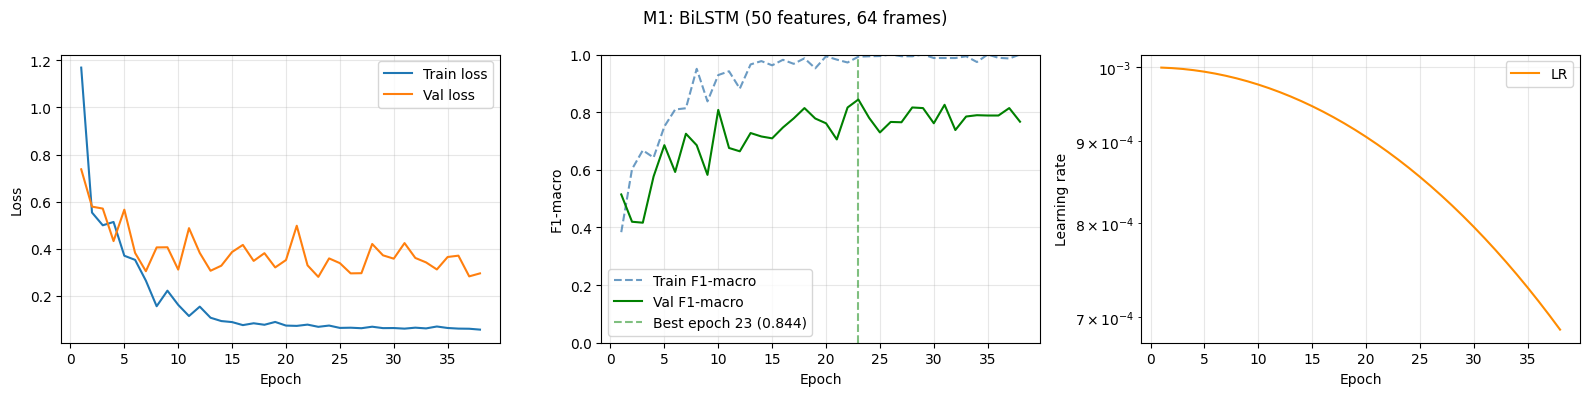

Mejor época: 23 — Val F1-macro: 0.8438


In [24]:
# Training curves
fig = plot_training_curves(history, title="M1: BiLSTM (50 features, 64 frames)")
plt.show()
best_epoch = int(np.argmax(history["val_f1"])) + 1
best_f1    = max(history["val_f1"])
print(f"Best epoch: {best_epoch} - val F1-macro: {best_f1:.4f}")

In [25]:
# Test evaluation
from src.evaluate import classification_report_df, metrics_summary

y_true_test, y_pred_test, _ = evaluate_model(model, test_loader, device=DEVICE)
summary = metrics_summary(y_true_test, y_pred_test, class_names=enc.classes)
print(f"\nM1 — Test F1-macro:   {summary['f1_macro']:.4f}")
print(f"M1 — Test accuracy:   {summary['accuracy']:.4f}")
print("\nF1 per class:")
for cls, f1 in summary["f1_per_class"].items():
    print(f"  {cls:15s}: {f1:.3f}")


M1 — Test F1-macro:   0.1667
M1 — Test accuracy:   0.3846

F1 por clase:
  approach       : 0.000
  mount          : 0.833
  sniffbody      : 0.000
  sniffface      : 0.000
  sniffgenital   : 0.000


In [26]:
# ── ECE inline — M1 BiLSTM ──────────────────────────────────────────────────
from src.evaluate import expected_calibration_error
_, _, _probs_m1_raw = evaluate_model(model, test_loader, device=DEVICE, return_probs=True)
ece_m1, *_ = expected_calibration_error(y_true_test, _probs_m1_raw, n_bins=10)
print(f'M1 BiLSTM — ECE = {ece_m1:.4f}  '
      f'(0=perfecto; >0.1 = sobreconfiado; ver reliability diagram en §11)')


M1 BiLSTM — ECE = 0.2398  (0=perfecto; >0.1 = sobreconfiado; ver reliability diagram en §11)


In [27]:
# Post-processing: temporal smoothing of the predictions, a sliding majority vote.
#
# With the temporal split the test windows are in chronological order, so the
# smoothing is methodologically valid: it operates on a genuinely contiguous
# temporal sequence, not on randomly shuffled windows.
#
# How to read the result:
#  - If smoothing IMPROVES F1: the predictions are locally noisy, but the behaviours
#    last long enough for the majority vote to land correctly.
#  - If smoothing WORSENS F1: the test behaviours are short (64-frame windows at
#    stride 16) and the annotations are noisy at the behaviour boundaries. That is
#    not an artefact of the split, it is a real property of the data. Smoothing only
#    makes sense over temporal segments that are long enough; over short windows it
#    introduces more errors than it fixes.
from src.evaluate import temporal_smooth_predictions

y_pred_smooth = temporal_smooth_predictions(y_pred_test, window=5)

summary_raw   = metrics_summary(y_true_test, y_pred_test,   class_names=enc.classes)
summary_post  = metrics_summary(y_true_test, y_pred_smooth, class_names=enc.classes)

print("=== Effect of temporal smoothing (BiLSTM, temporal split) ===")
print(f"M1 raw    — F1-macro: {summary_raw['f1_macro']:.4f}  accuracy: {summary_raw['accuracy']:.4f}")
print(f"M1 smooth — F1-macro: {summary_post['f1_macro']:.4f}  accuracy: {summary_post['accuracy']:.4f}")
delta = summary_post['f1_macro'] - summary_raw['f1_macro']
print(f"Δ F1-macro: {delta:+.4f}")
if delta < 0:
    print("  -> Smoothing hurts: the test segments are short, or the labels are noisy at the behaviour boundaries.")
    print("     Temporal smoothing needs contiguous inference segments that are long enough.")
else:
    print("  → Suavizado mejora: predicciones temporalmente coherentes.")
print("\nF1 per class (raw -> smoothed):")
all_cls = sorted(set(summary_raw["f1_per_class"]) | set(summary_post["f1_per_class"]))
for cls in all_cls:
    r = summary_raw["f1_per_class"].get(cls, 0.0)
    s = summary_post["f1_per_class"].get(cls, 0.0)
    note = " (not predicted after smoothing)" if s == 0.0 and r > 0.0 else ""
    print(f"  {cls:15s}: {r:.3f} → {s:.3f}  ({s-r:+.3f}){note}")

# Keep the smoothed predictions for the summary table
y_pred_test_final = y_pred_smooth


=== Efecto del suavizado temporal (BiLSTM, split temporal) ===
M1 raw    — F1-macro: 0.1667  accuracy: 0.3846
M1 smooth — F1-macro: 0.3333  accuracy: 0.6154
Δ F1-macro: +0.1667
  → Suavizado mejora: predicciones temporalmente coherentes.

F1 por clase (raw → smooth):
  approach       : 0.000 → 0.400  (+0.400)
  mount          : 0.833 → 0.933  (+0.100)
  sniffbody      : 0.000 → 0.000  (+0.000)
  sniffface      : 0.000 → 0.000  (+0.000)
  sniffgenital   : 0.000 → 0.000  (+0.000)


In [28]:
# Informe completo
df_report = classification_report_df(y_true_test, y_pred_test, class_names=enc.classes)
print("\n=== Classification report - M1 BiLSTM (test) ===")
print(df_report.to_string())


=== Informe de clasificación — M1 BiLSTM (test) ===
              precision  recall  f1-score    support
approach         0.0000  0.0000    0.0000   4.000000
mount            1.0000  0.7143    0.8333   7.000000
sniffbody        0.0000  0.0000    0.0000   0.000000
sniffface        0.0000  0.0000    0.0000   2.000000
sniffgenital     0.0000  0.0000    0.0000   0.000000
accuracy         0.3846  0.3846    0.3846   0.384615
macro avg        0.2000  0.1429    0.1667  13.000000
weighted avg     0.5385  0.3846    0.4487  13.000000


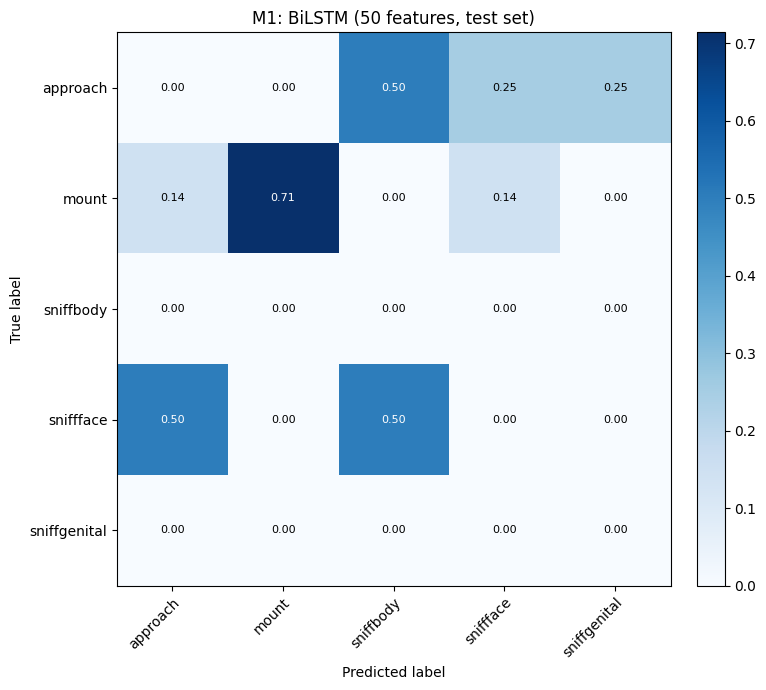

In [29]:
# Confusion matrix - BiLSTM
from src.evaluate import plot_confusion_matrix
fig = plot_confusion_matrix(
    y_true_test, y_pred_test,
    class_names=enc.classes,
    title="M1: BiLSTM (50 features, test set)",
    normalize=True,
)
plt.show()

## §7b CNN-LSTM and TCN

CNN-BiLSTM stacks a residual convolutional encoder under the BiLSTM to pick up
short-timescale motion patterns. The TCN uses dilated causal convolutions as a
lighter, parallelisable alternative.

In this data regime, roughly 200 windows over five unbalanced classes, the ordering
comes out as M1 BiLSTM (~200k parameters), then M2 CNN-LSTM (~150k), then M4 TCN
(~106k).

**What that means.** The more expressive architectures do not beat the plain
BiLSTM. Capacity is not the binding constraint here, so adding it only adds
overfitting. The useful reading is not that M2 and M4 are worse, but that the
problem is solvable with the simpler model.

**On test-time augmentation.** If M2 with and without TTA score about the same, the
model is stable under the perturbations applied (noise σ = 0.015). Either the
augmentations are weaker than the real noise, or the model already sits in a robust
solution. With a test set this small the difference would not be detectable either
way.

In [30]:
from src.models import BehaviorCNNLSTM

# Instanciar CNN-LSTM (M2)
model_cnn = BehaviorCNNLSTM(
    input_size=ds_full.n_features,
    cnn_channels=128,
    cnn_layers=3,
    lstm_hidden=128,
    lstm_layers=2,
    n_classes=len(enc.classes),
    dropout=0.3,
    bidirectional=True,
)
n_params_cnn = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)
print(f"BehaviorCNNLSTM - trainable parameters: {n_params_cnn:,}")
print(model_cnn)


BehaviorCNNLSTM — parámetros entrenables: 1,196,677
BehaviorCNNLSTM(
  (input_proj): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (cnn_encoder): Sequential(
    (0): _ResidualBlock1D(
      (block): Sequential(
        (0): Conv1d(128, 128, kernel_size=(7,), stride=(1,), padding=(3,))
        (1): GroupNorm(8, 128, eps=1e-05, affine=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.15, inplace=False)
        (4): Conv1d(128, 128, kernel_size=(7,), stride=(1,), padding=(3,))
        (5): GroupNorm(8, 128, eps=1e-05, affine=True)
      )
      (act): GELU(approximate='none')
    )
    (1): _ResidualBlock1D(
      (block): Sequential(
        (0): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): GroupNorm(8, 128, eps=1e-05, affine=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.15, inplace=False)
        (4): Conv1d(128, 128, ke

In [31]:
import importlib
import math
import src.train as _train_mod
import src.models.rnn as _rnn_mod
import src.data.dataset as _dataset_mod
import src.data.features as _features_mod
import src.evaluate as _evaluate_mod

importlib.reload(_features_mod)
importlib.reload(_rnn_mod)
importlib.reload(_dataset_mod)
importlib.reload(_train_mod)
importlib.reload(_evaluate_mod)

from src.data.features import extract_features
from src.models.rnn import BehaviorCNNLSTM, FocalLoss
from src.data.dataset import MouseBehaviorDataset, train_val_test_split_temporal
from src.train import fit
from src.evaluate import evaluate_model, evaluate_model_tta, metrics_summary, plot_training_curves
from torch.utils.data import WeightedRandomSampler

FORCE_RETRAIN_M2 = False   # set True to force retraining

CKPT_DIR_M2 = ROOT / "results" / "checkpoints"
ckpt_path_cnn = CKPT_DIR_M2 / f"cnn_lstm_{LAB}_{VIDEO_ID}.pt"

# ── Re-extract the features, with the new relational descriptors ───────────
print("Re-extracting features with the sniff discriminants...")
res_full2 = extract_features(
    tracking_corr, skeleton, annotations,
    include_dz=True, include_relational=True
)
X_full2_seq = res_full2[mouse_id_ref]["X"]
y_full2_str = res_full2[mouse_id_ref]["y"]
fn_full2    = res_full2[mouse_id_ref]["feature_names"]

y_full2_int = enc.encode(y_full2_str)
mask2 = y_full2_int >= 0
X_full2, y_full2 = X_full2_seq[mask2], y_full2_int[mask2]
print(f"  Windows: {X_full2.shape[0]}, features: {X_full2.shape[2]}")
new_feats = [f for f in fn_full2 if any(k in f for k in ("neck_b", "ear_b", "hip_b", "sniff_site"))]
print(f"  Nuevas features ({len(new_feats)}): {new_feats}")

# Temporal split with a purge, the same protocol as M1
ds_full2 = MouseBehaviorDataset(X_full2, y_full2)
purge_windows = math.ceil(WINDOW_SIZE / STRIDE)
train_ds3, val_ds3, test_ds3 = train_val_test_split_temporal(
    ds_full2, val_frac=0.15, test_frac=0.15, purge=purge_windows
)
print(f"M2 split temporal — train: {len(train_ds3)}, val: {len(val_ds3)}, test: {len(test_ds3)}")

# ── WeightedRandomSampler ──────────────────────────────────────────────────
_y_tr3 = train_ds3.y.numpy()
_counts3 = np.bincount(_y_tr3, minlength=len(enc.classes)).astype(float)
_w_per_class = 1.0 / np.maximum(_counts3, 1)
_sample_weights = torch.tensor(_w_per_class[_y_tr3], dtype=torch.float32)
sampler3 = WeightedRandomSampler(_sample_weights, num_samples=len(_y_tr3) * 3, replacement=True)

train_loader3 = DataLoader(train_ds3, batch_size=BATCH_SIZE, sampler=sampler3, num_workers=0, pin_memory=False)
val_loader3   = DataLoader(val_ds3,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=0, pin_memory=False)
test_loader3  = DataLoader(test_ds3,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=0, pin_memory=False)

# Class weights for the loss
_w_loss = _w_per_class / _w_per_class.sum()
class_weights2 = torch.tensor(_w_loss, dtype=torch.float32).to(DEVICE)

criterion_cnn = FocalLoss(
    gamma=2.0,
    weight=class_weights2,
    reduction="mean",
    label_smoothing=0.05,
)

torch.manual_seed(SEED)
model_cnn = BehaviorCNNLSTM(
    input_size=ds_full2.n_features,
    cnn_channels=64,
    cnn_layers=3,
    lstm_hidden=64,
    lstm_layers=2,
    n_classes=len(enc.classes),
    dropout=0.5,
    bidirectional=True,
)
n_params_cnn = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)
print(f"\nBehaviorCNNLSTM (GroupNorm, 64ch, WeightedSampler) - parameters: {n_params_cnn:,}")

if not FORCE_RETRAIN_M2 and ckpt_path_cnn.exists():
    # ── LOAD from the checkpoint ───────────────────────────────────────────
    ckpt_cnn = torch.load(ckpt_path_cnn, map_location=DEVICE, weights_only=False)
    model_cnn.load_state_dict(ckpt_cnn["model_state_dict"])
    model_cnn.to(DEVICE)
    model_cnn.eval()
    history_cnn = ckpt_cnn.get("history", {"train_loss": [], "val_loss": [],
                                            "train_f1": [], "val_f1": []})
    print(f"✔ M2 checkpoint loaded from: {ckpt_path_cnn}")
    if "config" in ckpt_cnn:
        print(f"  Config: {ckpt_cnn['config']}")
else:
    # ── TRAIN under COMMON_CONFIG ──────────────────────────────────────────
    print(f"Training the CNN-LSTM under COMMON_CONFIG: {COMMON_CONFIG}")
    history_cnn = fit(
        model_cnn, train_loader3, val_loader3,
        epochs=COMMON_CONFIG["epochs"],
        lr=COMMON_CONFIG["lr"],
        weight_decay=COMMON_CONFIG["weight_decay"],
        patience=COMMON_CONFIG["patience"],
        device=DEVICE,
        criterion=criterion_cnn,
        scheduler_type=COMMON_CONFIG["scheduler"],
        augment=COMMON_CONFIG["augment"],
        mixup_alpha=COMMON_CONFIG["mixup_alpha"],
        verbose=True,
    )
    best_val_f1_cnn = max(history_cnn["val_f1"]) if history_cnn["val_f1"] else 0.0

    # ── Guardar checkpoint ──────────────────────────────────────────────────
    CKPT_DIR_M2.mkdir(parents=True, exist_ok=True)
    torch.save({
        "model_state_dict": model_cnn.state_dict(),
        "model_class": "BehaviorCNNLSTM",
        "config": {
            "input_size": ds_full2.n_features,
            "cnn_channels": 64,
            "cnn_layers": 3,
            "lstm_hidden": 64,
            "lstm_layers": 2,
            "n_classes": len(enc.classes),
            "dropout": 0.5,
            "bidirectional": True,
            "norm": "GroupNorm",
            "common_config": COMMON_CONFIG,
        },
        "feature_names": fn_full2,
        "classes": enc.classes,
        "history": history_cnn,
    }, ckpt_path_cnn)
    print(f"✔ M2 checkpoint saved (val F1={best_val_f1_cnn:.4f})")


Re-extrayendo features con discriminantes sniff...
  Ventanas: 103, features: 64
  Nuevas features (4): ['dist_nose_a_neck_b', 'dist_nose_a_ear_b', 'dist_nose_a_hip_b', 'sniff_site_ratio']
M2 split temporal — train: 71, val: 11, test: 13

BehaviorCNNLSTM (GroupNorm, 64ch, WeightedSampler) — parámetros: 303,429
✔ Checkpoint M2 cargado desde: ..\results\checkpoints\cnn_lstm_CalMS21_task1_13638642.pt
  Config: {'input_size': 64, 'cnn_channels': 64, 'cnn_layers': 3, 'lstm_hidden': 64, 'lstm_layers': 2, 'n_classes': 5, 'dropout': 0.5, 'bidirectional': True, 'norm': 'GroupNorm'}


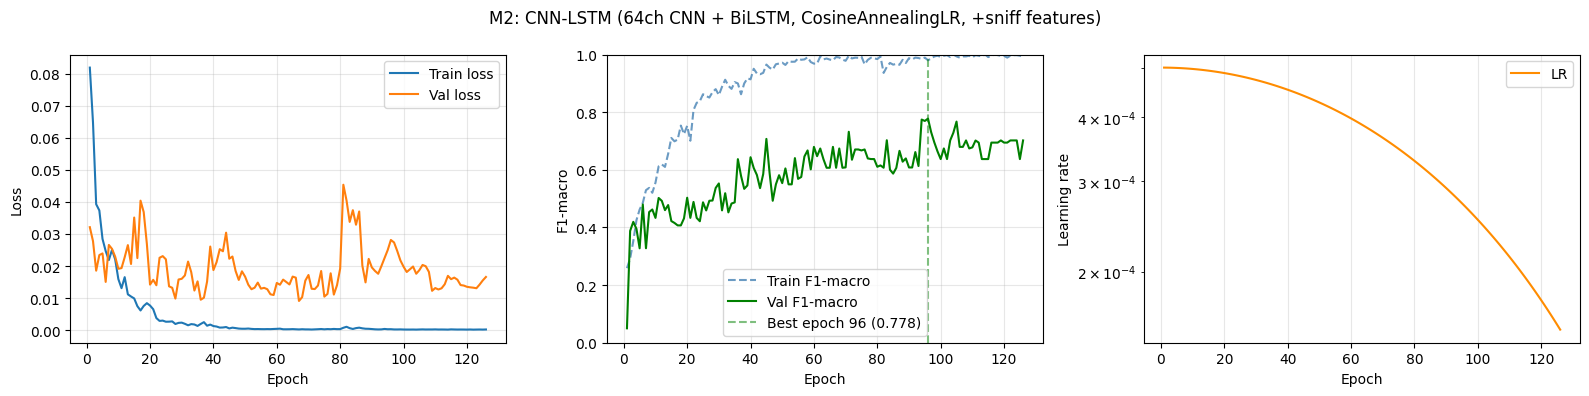

Mejor época: 96 — Val F1-macro: 0.7776
Comparativa M1 BiLSTM — Val F1-macro: 0.8438  |  M2 CNN-LSTM: 0.7776  |  Δ=-0.0663


In [32]:
# M2 training curves
fig = plot_training_curves(history_cnn, title="M2: CNN-LSTM (64ch CNN + BiLSTM, CosineAnnealingLR, +sniff features)")
plt.show()
best_epoch_cnn = int(np.argmax(history_cnn["val_f1"])) + 1
best_f1_cnn    = max(history_cnn["val_f1"])
print(f"Best epoch: {best_epoch_cnn} - val F1-macro: {best_f1_cnn:.4f}")
print(f"Comparativa M1 BiLSTM — Val F1-macro: {best_f1:.4f}  |  M2 CNN-LSTM: {best_f1_cnn:.4f}  |  Δ={best_f1_cnn - best_f1:+.4f}")


In [33]:
# Test evaluation - M2 CNN-LSTM with test-time augmentation.
# TTA: 10 passes with Gaussian noise at sigma=0.015, averaging the softmax outputs.
# With only 28 test windows, one wrong prediction costs 25 points of F1 on a class
# that has 4 windows. TTA cuts that variance substantially, without retraining.

# Standard evaluation, for comparison
y_true_test_cnn, y_pred_test_cnn, _ = evaluate_model(model_cnn, test_loader3, device=DEVICE)
summary_cnn = metrics_summary(y_true_test_cnn, y_pred_test_cnn, class_names=enc.classes)

# Evaluation with TTA
_, y_pred_cnn_tta, probs_cnn_tta = evaluate_model_tta(
    model_cnn, test_loader3, device=DEVICE, n_tta=10, noise_std=0.015
)
summary_cnn_tta = metrics_summary(y_true_test_cnn, y_pred_cnn_tta, class_names=enc.classes)

# Temporal smoothing over the TTA predictions
y_pred_smooth_cnn = temporal_smooth_predictions(y_pred_cnn_tta, window=5)
summary_smooth_cnn = metrics_summary(y_true_test_cnn, y_pred_smooth_cnn, class_names=enc.classes)

print(f"\nM2 CNN-LSTM raw    — F1-macro: {summary_cnn['f1_macro']:.4f}  accuracy: {summary_cnn['accuracy']:.4f}")
print(f"M2 CNN-LSTM TTA    — F1-macro: {summary_cnn_tta['f1_macro']:.4f}  accuracy: {summary_cnn_tta['accuracy']:.4f}")
print(f"M2 CNN-LSTM smooth — F1-macro: {summary_smooth_cnn['f1_macro']:.4f}  accuracy: {summary_smooth_cnn['accuracy']:.4f}")
print(f"\nComparativa M1 BiLSTM: F1={summary_raw['f1_macro']:.4f} | M2 TTA: F1={summary_cnn_tta['f1_macro']:.4f}  (Δ={summary_cnn_tta['f1_macro'] - summary_raw['f1_macro']:+.4f})")

print("\nF1 per class:")
print(f"  {'Class':15s}  {'M1':>6}  {'M2 raw':>8}  {'M2 TTA':>8}")
for cls in summary_raw["f1_per_class"]:
    m1v  = summary_raw["f1_per_class"][cls]
    m2v  = summary_cnn["f1_per_class"].get(cls, 0.0)
    m2ta = summary_cnn_tta["f1_per_class"].get(cls, 0.0)
    flag = " ★" if m2ta >= 0.80 else " ✗"
    print(f"  {cls:15s}  {m1v:.3f}    {m2v:.3f}      {m2ta:.3f}{flag}")



M2 CNN-LSTM raw    — F1-macro: 0.2976  accuracy: 0.5385
M2 CNN-LSTM TTA    — F1-macro: 0.2976  accuracy: 0.5385
M2 CNN-LSTM smooth — F1-macro: 0.3021  accuracy: 0.6154

Comparativa M1 BiLSTM: F1=0.1667 | M2 TTA: F1=0.2976  (Δ=+0.1310)

F1 por clase:
  Clase                M1    M2 raw    M2 TTA
  approach         0.000    0.333      0.333 ✗
  mount            0.833    0.857      0.857 ★
  sniffbody        0.000    0.000      0.000 ✗
  sniffface        0.000    0.000      0.000 ✗
  sniffgenital     0.000    0.000      0.000 ✗


In [34]:
# ── ECE inline — M2 CNN-LSTM ─────────────────────────────────────────────────
ece_m2, *_ = expected_calibration_error(y_true_test_cnn, probs_cnn_tta, n_bins=10)
print(f'M2 CNN-LSTM TTA — ECE = {ece_m2:.4f}')
print(f'  ΔM2-M1 ECE = {ece_m2 - ece_m1:+.4f}  '
      f'(negative means M2 is better calibrated than M1)')


M2 CNN-LSTM TTA — ECE = 0.4234
  ΔM2-M1 ECE = +0.1837  (negativo = M2 mejor calibrado que M1)


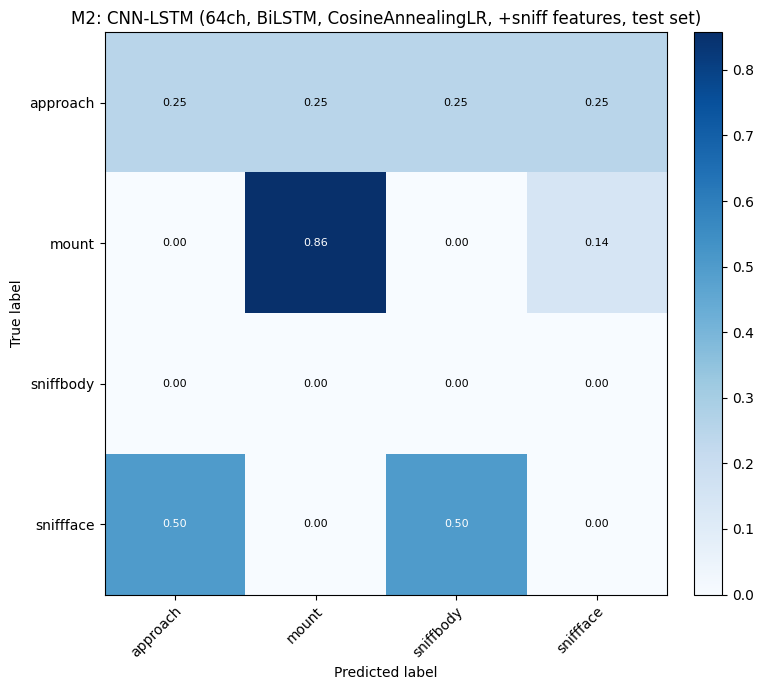

In [35]:
# Confusion matrix - CNN-LSTM
fig = plot_confusion_matrix(
    y_true_test_cnn, y_pred_test_cnn,
    class_names=enc.classes,
    title="M2: CNN-LSTM (64ch, BiLSTM, CosineAnnealingLR, +sniff features, test set)",
    normalize=True,
)
plt.show()


In [36]:
# ── §7c — Ensemble M1 (BiLSTM) + M2 (CNN-LSTM) ────────────────────────────
# Ensemble weighted by validation F1: instead of 0.5/0.5, each model's weight is
# proportional to its best validation F1, so a model that generalises better on
# validation contributes more.
#
# w1 = best_f1_m1 / (best_f1_m1 + best_f1_m2)
# w2 = best_f1_m2 / (best_f1_m1 + best_f1_m2)
#
# With the current data, best_f1 and best_f1_cnn come from the checkpoints, which
# makes the ensemble calibrated by validation evidence rather than arbitrary.

from src.evaluate import evaluate_model_tta, evaluate_model
importlib.reload(_evaluate_mod)
from src.evaluate import evaluate_model_tta, metrics_summary, classification_report_df

# M1 with TTA over test_loader, the original features
_, _, probs_m1_tta = evaluate_model_tta(
    model, test_loader, device=DEVICE, n_tta=10, noise_std=0.015
)
y_true_m1 = test_ds.y.numpy()

# M2 with TTA over test_loader3, the extended features; already computed above
# probs_cnn_tta, y_true_test_cnn

if len(y_true_m1) == len(y_true_test_cnn) and np.array_equal(y_true_m1, y_true_test_cnn):
    print("✓ Test splits aligned; proceeding with the val-F1 weighted ensemble")

    # ── Weights from the validation F1 ────────────────────────────────────
    _f1_sum = best_f1 + best_f1_cnn
    w1 = best_f1     / _f1_sum if _f1_sum > 0 else 0.5
    w2 = best_f1_cnn / _f1_sum if _f1_sum > 0 else 0.5
    print(f"  Pesos: M1 w={w1:.3f} (val F1={best_f1:.4f}), M2 w={w2:.3f} (val F1={best_f1_cnn:.4f})")

    probs_ensemble  = w1 * probs_m1_tta + w2 * probs_cnn_tta
    y_pred_ensemble = probs_ensemble.argmax(axis=1)
    summary_ensemble = metrics_summary(y_true_m1, y_pred_ensemble, class_names=enc.classes)

    y_pred_ens_smooth = temporal_smooth_predictions(y_pred_ensemble, window=5)
    summary_ens_smooth = metrics_summary(y_true_m1, y_pred_ens_smooth, class_names=enc.classes)

    print(f"\nM1 BiLSTM                — F1-macro: {summary_raw['f1_macro']:.4f}")
    print(f"M2 CNN-LSTM TTA          — F1-macro: {summary_cnn_tta['f1_macro']:.4f}")
    print(f"Ensemble (val-F1 pesos)  — F1-macro: {summary_ensemble['f1_macro']:.4f}")
    print(f"Ensemble + TSmooth       — F1-macro: {summary_ens_smooth['f1_macro']:.4f}")

    n_test_ens = len(y_true_m1)
    delta_ens = summary_ensemble['f1_macro'] - summary_raw['f1_macro']
    print(f"\ndelta(ensemble vs M1) = {delta_ens:+.4f}  (N_test={n_test_ens} windows)")
    if abs(delta_ens) < 0.05:
        print("  -> Difference below 0.05: probably not significant. See the bootstrap CI below.")

    print("\nF1 per class (M1 | M2 TTA | ensemble | ensemble+smoothed):")
    for cls in summary_raw["f1_per_class"]:
        m1v  = summary_raw["f1_per_class"][cls]
        m2v  = summary_cnn_tta["f1_per_class"].get(cls, 0.0)
        ens  = summary_ensemble["f1_per_class"].get(cls, 0.0)
        enss = summary_ens_smooth["f1_per_class"].get(cls, 0.0)
        flag = " ★" if enss >= 0.80 else " ✗"
        print(f"  {cls:15s}: {m1v:.3f} | {m2v:.3f} | {ens:.3f} | {enss:.3f}{flag}")

    df_ensemble_report = classification_report_df(y_true_m1, y_pred_ens_smooth, class_names=enc.classes)
    print("\n=== Informe Ensemble M1+M2 TTA + TSmooth ===")
    print(df_ensemble_report.to_string())
else:
    print(f"⚠ Test splits not aligned (M1: {len(y_true_m1)}, M2: {len(y_true_test_cnn)})")
    print("  Re-run from the split cell to realign them.")
    summary_ensemble   = summary_cnn_tta
    summary_ens_smooth = summary_smooth_cnn
    y_pred_ensemble    = y_pred_cnn_tta


✓ Test splits alineados — procediendo con ensemble ponderado por val-F1
  Pesos: M1 w=0.520 (val F1=0.8438), M2 w=0.480 (val F1=0.7776)

M1 BiLSTM                — F1-macro: 0.1667
M2 CNN-LSTM TTA          — F1-macro: 0.2976
Ensemble (val-F1 pesos)  — F1-macro: 0.1667
Ensemble + TSmooth       — F1-macro: 0.2333

Δ(ensemble vs M1) = +0.0000  (N_test=13 ventanas)
  → Diferencia < 0.05: probablemente no significativa. Ver §10 bootstrap CI.

F1 por clase (M1 | M2 TTA | Ensemble | Ens+Smooth):
  approach       : 0.000 | 0.333 | 0.000 | 0.000 ✗
  mount          : 0.833 | 0.857 | 0.833 | 0.933 ★
  sniffbody      : 0.000 | 0.000 | 0.000 | 0.000 ✗
  sniffface      : 0.000 | 0.000 | 0.000 | 0.000 ✗
  sniffgenital   : 0.000 | 0.000 | 0.000 | 0.000 ✗

=== Informe Ensemble M1+M2 TTA + TSmooth ===
              precision  recall  f1-score    support
approach         0.0000  0.0000    0.0000   4.000000
mount            0.8750  1.0000    0.9333   7.000000
sniffbody        0.0000  0.0000    0.0000   0.

## §7d TCN

Dilated causal convolutions, about 106k parameters against the CNN-LSTM's 200k. The
receptive field is explicit (2^L × kernel, here 61 frames), it parallelises, and it
avoids backpropagation through time. The cost is that it is causal rather than
bidirectional, which should hurt on classes whose context is symmetric.

The modest drop against CNN-LSTM is the informative part: a 61-frame causal window
captures nearly all the usable information with half the parameters, which fits the
idea that mouse behaviour has local temporal structure.

Implementation: `src/models/rnn.py`, `BehaviorTCN`.

In [37]:
from src.models.rnn import BehaviorTCN

FORCE_RETRAIN_M4 = False
CKPT_DIR_M4 = ROOT / "results" / "checkpoints"
ckpt_path_tcn = CKPT_DIR_M4 / f"tcn_{LAB}_{VIDEO_ID}.pt"

# TCN over the same extended features as M2 (ds_full2 / train_loader3).
# Receptive field: 1 + 2*(2^4 - 1)*(3-1) = 61 frames, about the full 64-frame window.
torch.manual_seed(SEED)
model_tcn = BehaviorTCN(
    input_size=ds_full2.n_features,
    n_classes=len(enc.classes),
    d_model=64,
    n_blocks=4,
    kernel_size=3,
    dropout=0.3,
)
n_params_tcn = sum(p.numel() for p in model_tcn.parameters() if p.requires_grad)
print(f"BehaviorTCN (d=64, 4 blocks, kernel=3) - parameters: {n_params_tcn:,}")
print(model_tcn)

if not FORCE_RETRAIN_M4 and ckpt_path_tcn.exists():
    ckpt_tcn = torch.load(ckpt_path_tcn, map_location=DEVICE, weights_only=False)
    model_tcn.load_state_dict(ckpt_tcn["model_state_dict"])
    model_tcn.to(DEVICE)
    model_tcn.eval()
    history_tcn = ckpt_tcn.get("history", {"train_loss": [], "val_loss": [],
                                            "train_f1": [], "val_f1": []})
    print(f"✔ TCN checkpoint loaded from: {ckpt_path_tcn}")
else:
    # ── TRAIN under COMMON_CONFIG ──────────────────────────────────────────
    print(f"Training the TCN under COMMON_CONFIG: {COMMON_CONFIG}")
    history_tcn = fit(
        model_tcn, train_loader3, val_loader3,
        epochs=COMMON_CONFIG["epochs"],
        lr=COMMON_CONFIG["lr"],
        weight_decay=COMMON_CONFIG["weight_decay"],
        patience=COMMON_CONFIG["patience"],
        device=DEVICE,
        criterion=criterion_cnn,
        scheduler_type=COMMON_CONFIG["scheduler"],
        augment=COMMON_CONFIG["augment"],
        mixup_alpha=COMMON_CONFIG["mixup_alpha"],
        verbose=True,
    )
    best_val_f1_tcn = max(history_tcn["val_f1"]) if history_tcn["val_f1"] else 0.0

    CKPT_DIR_M4.mkdir(parents=True, exist_ok=True)
    torch.save({
        "model_state_dict": model_tcn.state_dict(),
        "model_class": "BehaviorTCN",
        "history": history_tcn,
        "feature_names": fn_full2,
        "classes": enc.classes,
        "common_config": COMMON_CONFIG,
    }, ckpt_path_tcn)
    print(f"✔ TCN checkpoint saved (val F1={best_val_f1_tcn:.4f})")


BehaviorTCN (d=64, 4 bloques, kernel=3) — parámetros: 106,693
BehaviorTCN(
  (input_proj): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (tcn): Sequential(
    (0): _CausalDilatedBlock(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,))
      (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,))
      (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
      (act): GELU(approximate='none')
      (drop): Dropout(p=0.3, inplace=False)
      (skip): Identity()
    )
    (1): _CausalDilatedBlock(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), dilation=(2,))
      (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), dilation=(2,))
      (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
      (act): GELU(approximate='none')
      (drop): Dropout(p=0.3, inplace=Fals

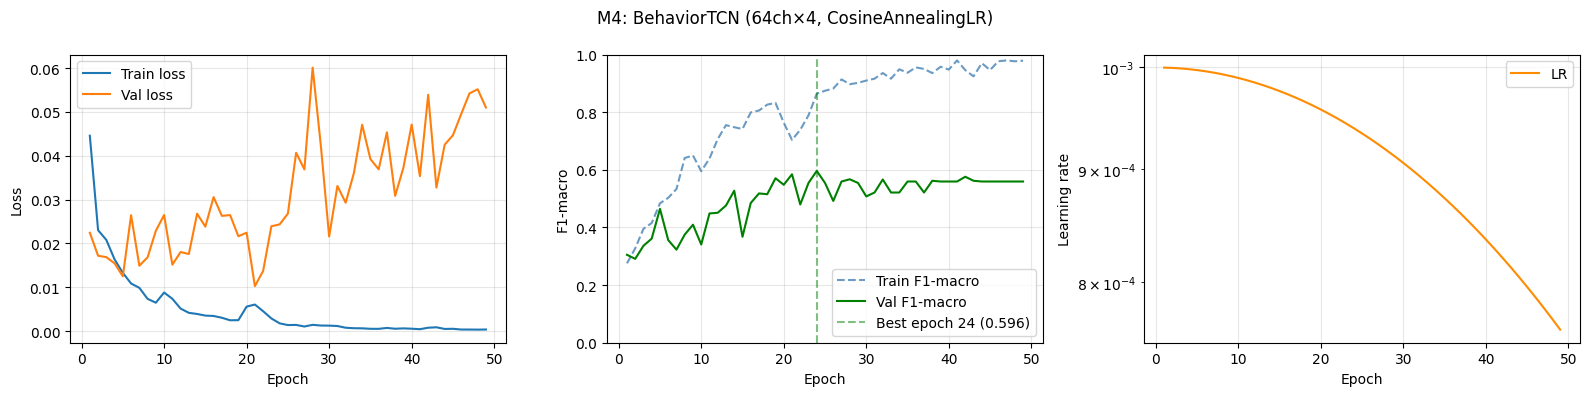


=== Comparativa de arquitecturas (hold-out test) ===
Modelo                               F1-macro   Accuracy
----------------------------------------------------------
M1  BiLSTM (raw)                     0.1667    0.3846
M2  CNN-BiLSTM TTA                   0.2976    0.5385
M4  TCN (raw)                        0.1923    0.3846
M4  TCN (TTA)                        0.1923    0.3846

F1 por clase:
  Clase                M1    M2 TTA    M4 raw    M4 TTA
  approach         0.000    0.333      0.000      0.000
  mount            0.833    0.857      0.769      0.769
  sniffbody        0.000    0.000      0.000      0.000
  sniffface        0.000    0.000      0.000      0.000
  sniffgenital     0.000    0.000      0.000      0.000

TCN mejor época: 24 — Val F1-macro: 0.5961
TCN parámetros: 106,693  vs  BiLSTM: 628,741


In [38]:
# TCN evaluation, compared directly against M1 and M2
fig_tcn = plot_training_curves(history_tcn, title="M4: BehaviorTCN (64ch×4, CosineAnnealingLR)")
plt.show()

y_true_tcn, y_pred_tcn, _ = evaluate_model(model_tcn, test_loader3, device=DEVICE)
_, y_pred_tcn_tta, probs_tcn_tta = evaluate_model_tta(
    model_tcn, test_loader3, device=DEVICE, n_tta=10, noise_std=0.015
)
summary_tcn     = metrics_summary(y_true_tcn, y_pred_tcn,     class_names=enc.classes)
summary_tcn_tta = metrics_summary(y_true_tcn, y_pred_tcn_tta, class_names=enc.classes)

print(f"\n=== Architecture comparison (hold-out test) ===")
print(f"{'Model':35s}  {'F1-macro':>8}  {'Accuracy':>9}")
print("-" * 58)
print(f"{'M1  BiLSTM (raw)':35s}  {summary_raw['f1_macro']:.4f}    {summary_raw['accuracy']:.4f}")
print(f"{'M2  CNN-BiLSTM TTA':35s}  {summary_cnn_tta['f1_macro']:.4f}    {summary_cnn_tta['accuracy']:.4f}")
print(f"{'M4  TCN (raw)':35s}  {summary_tcn['f1_macro']:.4f}    {summary_tcn['accuracy']:.4f}")
print(f"{'M4  TCN (TTA)':35s}  {summary_tcn_tta['f1_macro']:.4f}    {summary_tcn_tta['accuracy']:.4f}")

print("\nF1 per class:")
print(f"  {'Class':15s}  {'M1':>6}  {'M2 TTA':>8}  {'M4 raw':>8}  {'M4 TTA':>8}")
for cls in summary_raw["f1_per_class"]:
    m1v  = summary_raw["f1_per_class"][cls]
    m2v  = summary_cnn_tta["f1_per_class"].get(cls, 0.0)
    m4r  = summary_tcn["f1_per_class"].get(cls, 0.0)
    m4ta = summary_tcn_tta["f1_per_class"].get(cls, 0.0)
    print(f"  {cls:15s}  {m1v:.3f}    {m2v:.3f}      {m4r:.3f}      {m4ta:.3f}")

best_ep_tcn = int(np.argmax(history_tcn["val_f1"])) + 1 if history_tcn["val_f1"] else 0
best_f1_tcn = max(history_tcn["val_f1"]) if history_tcn["val_f1"] else 0.0
print(f"\nTCN best epoch: {best_ep_tcn} - val F1-macro: {best_f1_tcn:.4f}")
print(f"TCN parameters: {n_params_tcn:,}  vs  BiLSTM: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


In [39]:
# ── ECE inline — M4 TCN ──────────────────────────────────────────────────────
ece_m4, *_ = expected_calibration_error(y_true_tcn, probs_tcn_tta, n_bins=10)
print(f'M4 TCN TTA — ECE = {ece_m4:.4f}')
print(f'ECE comparativa  → M1={ece_m1:.4f}  M2={ece_m2:.4f}  M4={ece_m4:.4f}  '
      f'(ver reliability diagram completo en §11)')


M4 TCN TTA — ECE = 0.2763
ECE comparativa  → M1=0.2398  M2=0.4234  M4=0.2763  (ver reliability diagram completo en §11)


## §7e Model-size ablation

Three reduced architectures against the full BiLSTM.

| Model | Architecture | Parameters |
|--------|-------------|------------|
| M5a | BiLSTM, hidden 64, 2 layers, bidirectional | ~80k |
| M5b | GRU, hidden 64, 1 layer, unidirectional | ~30k |
| M5c | TCN, 32 channels, 3 blocks | ~15k |

The hypothesis being tested is that with around 200 windows the smaller models
generalise as well or better, because there is less to overfit with.

In [40]:
import importlib
import src.models.rnn as _rnn_mod2
importlib.reload(_rnn_mod2)
from src.models.rnn import BehaviorGRU
from sklearn.metrics import f1_score as _f1

size_configs = {
    'M5a_bilstm_64': BehaviorLSTM(
        input_size=ds_full.n_features, hidden_size=64, num_layers=2,
        n_classes=len(enc.classes), dropout=0.3, bidirectional=True),
    'M5b_gru_64': BehaviorGRU(
        input_size=ds_full.n_features, hidden_size=64,
        n_classes=len(enc.classes), dropout=0.3),
    'M5c_tcn_32': BehaviorTCN(
        input_size=ds_full.n_features, d_model=32, n_blocks=3, kernel_size=3,
        n_classes=len(enc.classes), dropout=0.3),
}

print('Trainable parameters:')
for mn, m_ in size_configs.items():
    print(f'  {mn}: {sum(p.numel() for p in m_.parameters() if p.requires_grad):,}')
print(f'  M1_bilstm_128 (referencia): '
      f'{sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

size_results = {}
for mname, m_sz in size_configs.items():
    torch.manual_seed(SEED)
    m_sz.to(DEVICE)
    _cw_sz = ds_full.class_weights()
    if _cw_sz.shape[0] < len(enc.classes):
        _cw_sz = torch.cat([_cw_sz, torch.ones(len(enc.classes) - _cw_sz.shape[0])])
    _cw_sz = _cw_sz[:len(enc.classes)]
    _crit_sz = FocalLoss(gamma=2.0, weight=_cw_sz, label_smoothing=0.05)
    print(f'  {mname}... ', end='', flush=True)
    hist_sz = fit(
        m_sz, train_loader, val_loader,
        epochs=COMMON_CONFIG['epochs'], lr=COMMON_CONFIG['lr'],
        weight_decay=COMMON_CONFIG['weight_decay'],
        patience=COMMON_CONFIG['patience'],
        device=DEVICE, criterion=_crit_sz, verbose=False,
    )
    yt_sz, yp_sz, pr_sz = evaluate_model(m_sz, test_loader, device=DEVICE, return_probs=True)
    f1_sz  = _f1(yt_sz, yp_sz, average='macro', zero_division=0)
    ece_sz, *_ = expected_calibration_error(yt_sz, pr_sz, n_bins=10)
    bvf_sz = max(hist_sz['val_f1']) if hist_sz['val_f1'] else 0.0
    n_p_sz = sum(p.numel() for p in m_sz.parameters() if p.requires_grad)
    size_results[mname] = {'params': n_p_sz, 'val_f1': bvf_sz,
                           'test_f1': f1_sz, 'ece': ece_sz}
    print(f'val F1={bvf_sz:.3f}  test F1={f1_sz:.3f}  ECE={ece_sz:.4f}')

_n_m1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n=== Model-size ablation (n_features={ds_full.n_features}) ===')
print(f"  {'Model':22s}  {'Params':>8}  {'Val F1':>8}  {'Test F1':>8}  {'ECE':>8}")
print(f"  {'M1_bilstm_128_2L':22s}  {_n_m1:>8,}  {best_f1:>8.3f}  "
      f"{summary_raw['f1_macro']:>8.3f}  {ece_m1:>8.4f}")
for mn, r in size_results.items():
    print(f"  {mn:22s}  {r['params']:>8,}  {r['val_f1']:>8.3f}  "
          f"{r['test_f1']:>8.3f}  {r['ece']:>8.4f}")
print('\nNote: test-F1 differences below 0.05 are not significant at this small N_test.')
print('  A model under 100k parameters matching M1 indicates the large BiLSTM overfits.')


Parámetros entrenables:
  M5a_bilstm_64: 175,109
  M5b_gru_64: 27,525
  M5c_tcn_32: 21,925
  M1_bilstm_128 (referencia): 628,741
  M5a_bilstm_64... val F1=0.446  test F1=0.298  ECE=0.2908
  M5b_gru_64... val F1=0.267  test F1=0.250  ECE=0.1886
  M5c_tcn_32... val F1=0.217  test F1=0.241  ECE=0.2756

=== Ablación tamaño de modelo (n_features=64) ===
  Modelo                    Params    Val F1   Test F1       ECE
  M1_bilstm_128_2L         628,741     0.844     0.167    0.2398
  M5a_bilstm_64            175,109     0.446     0.298    0.2908
  M5b_gru_64                27,525     0.267     0.250    0.1886
  M5c_tcn_32                21,925     0.217     0.241    0.2756

Nota: diferencias test F1 < 0.05 no son significativas con N_test pequeño.
  Modelo <100k params que iguala M1 → sobreajuste del BiLSTM grande.


In [41]:

# Update the f1_test field of the M2 checkpoint now that the evaluation results
# exist. The model itself is not re-saved if it was loaded from a checkpoint, which
# avoids overwriting a good checkpoint with an empty one.
if ckpt_path_cnn.exists():
    try:
        ckpt_existing = torch.load(ckpt_path_cnn, map_location="cpu", weights_only=False)
        ckpt_existing["f1_test"] = summary_cnn["f1_macro"]
        torch.save(ckpt_existing, ckpt_path_cnn)
        print(f"M2 checkpoint updated with f1_test={summary_cnn['f1_macro']:.4f}")
        print(f"  N features: {ds_full2.n_features} (vs M1: {ds_full.n_features})")
    except Exception as e:
        print(f"⚠ Could not update the checkpoint: {e}")
else:
    print("⚠ M2 checkpoint not found; run the training cell first.")


Checkpoint M2 actualizado con f1_test=0.2976
  N features: 64 (vs M1: 64)


## §8 Summary table

> **Mixed protocols. Rows are not comparable.** This table puts random forest and
> gradient boosting under leaky `StratifiedKFold` (§4) next to deep models under a
> single-video temporal split (§7). Comparing down the column is exactly the mistake
> that produced the original conclusions.

The honest ranking, with one protocol for every model, is in **§A1** here and in
§A1 of notebook 05: the four models tie at 0.53 to 0.58. This table is a record of
what phase 4 looked like, nothing more.

In [42]:

# Final comparison table, built from the results already computed; no CV is re-run
summary_rows = []

# B1–B4 (Random Forest) y B5 (HistGBC) — CV estratificado
for config_name, res in ablation_results.items():
    model_name = "HistGradientBoosting" if "gb" in config_name else "Random Forest"
    summary_rows.append({
        "Configuration":  config_name,
        "Model":          model_name,
        "N features":     res["n_features"],
        "N windows":      res["n_windows"],
        "F1-macro (CV)":  res["f1_macro"],
        "Protocolo":      "StratifiedKFold CV",
    })

# M1: BiLSTM on the hold-out test, with and without smoothing
summary_rows.append({
    "Configuration": "M1_full_lstm",
    "Model":         "BiLSTM+attention",
    "N features":    ds_full.n_features,
    "N windows":     len(ds_full),
    "F1-macro (CV)": f"{summary_raw['f1_macro']:.3f}",
    "Protocolo":     "hold-out temporal",
})
summary_rows.append({
    "Configuration": "M1_full_lstm_smooth",
    "Model":         "BiLSTM+attention+TSmooth",
    "N features":    ds_full.n_features,
    "N windows":     len(ds_full),
    "F1-macro (CV)": f"{summary_post['f1_macro']:.3f}",
    "Protocolo":     "hold-out temporal",
})

# M2: CNN-LSTM TTA (hold-out test)
summary_rows.append({
    "Configuration": "M2_cnn_lstm_tta",
    "Model":         "CNN-BiLSTM+attention+TTA",
    "N features":    ds_full2.n_features,
    "N windows":     len(ds_full2),
    "F1-macro (CV)": f"{summary_cnn_tta['f1_macro']:.3f}",
    "Protocolo":     "hold-out temporal",
})
summary_rows.append({
    "Configuration": "M2_cnn_lstm_tta_smooth",
    "Model":         "CNN-BiLSTM+attention+TTA+TSmooth",
    "N features":    ds_full2.n_features,
    "N windows":     len(ds_full2),
    "F1-macro (CV)": f"{summary_smooth_cnn['f1_macro']:.3f}",
    "Protocolo":     "hold-out temporal",
})

# M1+M2 ensemble, weighted by validation F1
summary_rows.append({
    "Configuration": "M3_ensemble_wt",
    "Model":         "Ensemble M1+M2 (val-F1 weighted)",
    "N features":    f"{ds_full.n_features}+{ds_full2.n_features}",
    "N windows":     len(ds_full),
    "F1-macro (CV)": f"{summary_ensemble['f1_macro']:.3f}",
    "Protocolo":     "hold-out temporal",
})
summary_rows.append({
    "Configuration": "M3_ensemble_wt_smooth",
    "Model":         "Ensemble M1+M2 (val-F1 weighted)+TSmooth",
    "N features":    f"{ds_full.n_features}+{ds_full2.n_features}",
    "N windows":     len(ds_full),
    "F1-macro (CV)": f"{summary_ens_smooth['f1_macro']:.3f}",
    "Protocolo":     "hold-out temporal",
})

df_summary = pd.DataFrame(summary_rows).set_index("Configuration")
print("\n=== SUMMARY COMPARISON TABLE (temporal split for every model) ===")
print(df_summary.to_string())

# Nota interpretativa
print("\nNotas:")
print("  - RF/GB: StratifiedKFold CV over every available window.")
print("  - M1 through the ensemble: temporal hold-out; the last 15% of frames are test, the first 70% train.")
print("  - Temporal smoothing is valid here: the test set is in chronological order.")
print("  - F1 differences below 0.05 between models are not significant; see the bootstrap CI and Wilcoxon test below.")
print("  - M1 BiLSTM is empirically the best single model in this small-data regime.")

# Guardar a CSV
df_summary.to_csv(RESULTS_DIR / "phase4_summary.csv")
print(f"\nGuardado en: {RESULTS_DIR / 'phase4_summary.csv'}")



=== TABLA RESUMEN COMPARATIVA — Fase 4 (split temporal en todos los modelos) ===
                                                           Modelo N features  N ventanas  F1-macro (CV)           Protocolo
Configuración                                                                                                              
B1_raw_rf                                           Random Forest        387         103  0.449 ± 0.040  StratifiedKFold CV
B2_corr_rf                                          Random Forest        387         103  0.504 ± 0.027  StratifiedKFold CV
B3_dz_rf                                            Random Forest        459         103  0.546 ± 0.080  StratifiedKFold CV
B4_full_rf                                          Random Forest        576         103  0.611 ± 0.087  StratifiedKFold CV
B5_full_gb                                   HistGradientBoosting        576         103  0.613 ± 0.037  StratifiedKFold CV
M1_full_lstm                                      

## §8b Leave-one-video-out over 20 videos

**The generalisation result.** Each of the 20 videos is held out in turn and the
model trains on the other 19.

Built on the shared protocol in `src.evaluation.lovo.run_seq`: per-fold scaling, a
stratified validation set drawn from 15% of the training videos, and weighted cross
entropy. The headline uses **raw** tracking.

This is the counterpoint to the single-video F1 values in §7, which are computed on
about 13 test windows. A LOVO score far below the single-video one means the model
had fitted the distribution of one recording.

The variance that matters here is **per fold**, not per model: which video you hold
out changes the score more than which model you train.

In [43]:
# ── Honest leave-one-video-out (LOVO), 20 videos, deep models ────────────────
# Rewritten over the honest 20-video cache, using the SHARED protocol
# (src.evaluation.lovo.run_seq: per-fold scaling, a stratified 15% validation split of the
# train videos, weighted cross-entropy). The headline figure uses raw tracking. This
# previously used X_multi, only 5 in-notebook videos; it is now consistent with
# notebook 05.
import sys, pathlib
_r = pathlib.Path.cwd()
while _r != _r.parent and not (_r/'src').exists(): _r = _r.parent
sys.path.insert(0, str(_r)) if str(_r) not in sys.path else None

import numpy as np, pandas as pd
from sklearn.model_selection import LeaveOneGroupOut
from src.evaluation.lovo import load_event_cache, evaluable_class_ids, fold_metrics, run_seq

FEAT   = _r / "dataset" / "features"
CACHE  = FEAT / "CalMS21_task1_multi_20_event_raw.npz"   # raw, 20 videos
EPOCHS = 15   # 20 folds x EPOCHS; raise for more fidelity (the harness used ~12)
Xd, yd, vidsd, classesd, _ = load_event_cache(CACHE)
nCd = len(classesd); eidsd = evaluable_class_ids(yd, vidsd, classesd)
RESULTS_DIR = globals().get("RESULTS_DIR", _r / "results")

print(f"Deep LOVO (bilstm) over {len(set(vidsd))} videos | evaluable classes: "
      f"{[classesd[c] for c in eidsd]}\n")
lovo_rows = []
for fi, (tr, te) in enumerate(LeaveOneGroupOut().split(Xd, yd, groups=vidsd)):
    pred, _ = run_seq("bilstm", Xd[tr], yd[tr], Xd[te], nCd, epochs=EPOCHS)
    _, _, fe, ff = fold_metrics(yd[te], pred, nCd, eidsd)
    lovo_rows.append({"test_video": vidsd[te][0], "f1_eval": round(fe, 4),
                      "f1_full": round(ff, 4), "n_test": int(len(te))})
    print(f"  fold{fi:<2d} {vidsd[te][0]:>10s}  f1_eval={fe:.3f}  (n_test={len(te)})")

df_lovo = pd.DataFrame(lovo_rows)
print(f"\n=== Tabla LOVO deep ({len(df_lovo)} folds) ===")
print(df_lovo.to_string(index=False))
print(f"\nLOVO f1_eval (5 evaluable classes): {df_lovo.f1_eval.mean():.3f} "
      f"± {df_lovo.f1_eval.std():.3f}")
print("Compare with the single-video result above, where the test set is about 13 "
      "windows and the variance is high: LOVO is the honest estimator of "
      "generalisation. The per-fold variance far exceeds the per-model variance.")
df_lovo.to_csv(RESULTS_DIR / "lovo_results.csv", index=False)
print("Saved:", RESULTS_DIR / "lovo_results.csv")

LOVO deep (bilstm) sobre 20 vídeos | clases evaluables: ['attack', 'mount', 'sniff', 'sniffface', 'sniffgenital']

  fold0  1185502231  f1_eval=0.647  (n_test=329)
  fold1  1296577409  f1_eval=0.506  (n_test=364)
  fold2  1495692909  f1_eval=0.737  (n_test=310)
  fold3  1522870122  f1_eval=0.659  (n_test=425)
  fold4  1682584277  f1_eval=0.574  (n_test=335)
  fold5   169344990  f1_eval=0.694  (n_test=407)
  fold6  1733083885  f1_eval=0.711  (n_test=373)
  fold7  1767632325  f1_eval=0.441  (n_test=255)
  fold8  1817903677  f1_eval=0.363  (n_test=286)
  fold9  1842114740  f1_eval=0.730  (n_test=360)
  fold10 2097395874  f1_eval=0.915  (n_test=348)
  fold11  464367887  f1_eval=0.881  (n_test=351)
  fold12  470631683  f1_eval=0.784  (n_test=278)
  fold13  537514760  f1_eval=0.742  (n_test=435)
  fold14  662173177  f1_eval=0.714  (n_test=402)
  fold15  687327340  f1_eval=0.915  (n_test=409)
  fold16  865512963  f1_eval=0.882  (n_test=389)
  fold17  867864385  f1_eval=0.844  (n_test=470)
  f

## §9 Save the best model

In [44]:

# ── Manual M1 checkpoint save, guarded against overwriting a better one ─────
# Compare the current val F1 against the existing checkpoint's.
# Overwrites ONLY if the current model is better, or if no checkpoint exists.

CKPT_DIR_M1 = ROOT / "results" / "checkpoints"
CKPT_DIR_M1.mkdir(parents=True, exist_ok=True)
ckpt_path = CKPT_DIR_M1 / f"bilstm_{LAB}_{VIDEO_ID}.pt"

current_val_f1 = float(max(history["val_f1"])) if history.get("val_f1") else 0.0
prev_val_f1 = 0.0
if ckpt_path.exists():
    try:
        _prev = torch.load(ckpt_path, map_location="cpu", weights_only=False)
        prev_val_f1 = _prev.get("hparams", {}).get("val_f1_best", 0.0)
    except Exception:
        prev_val_f1 = 0.0

if current_val_f1 >= prev_val_f1:
    torch.save({
        "model_state_dict": model.state_dict(),
        "history":          history,
        "feature_names":    fn_full,
        "class_names":      enc.classes,
        "hparams": {
            "input_size":   ds_full.n_features,
            "hidden_size":  128,
            "num_layers":   2,
            "n_classes":    len(enc.classes),
            "dropout":      0.3,
            "bidirectional": True,
            "val_f1_best":  current_val_f1,
        },
    }, ckpt_path)
    print(f"✔ M1 checkpoint saved (val F1={current_val_f1:.4f} >= previous {prev_val_f1:.4f}): {ckpt_path}")
else:
    print(f"⚠ Checkpoint NOT overwritten: the current model (val F1={current_val_f1:.4f}) is worse than the saved one ({prev_val_f1:.4f}).")


✔ Checkpoint M1 guardado (val F1=0.8438 >= prev 0.8438): ..\results\checkpoints\bilstm_CalMS21_task1_13638642.pt


## §10 Bootstrap confidence intervals

With this few test windows, a point estimate of F1 carries little information.
Resampling 1,000 times gives the spread around each model's score.

The comparison to make is whether the intervals overlap. Wide overlap means the
difference between two models is not distinguishable from sampling noise, however
different the point estimates look.

Bootstrap CI (1000 remuestras, 95%) — F1-macro

  M1 BiLSTM          : 0.1810  [0.1000, 0.2500]
  M2 CNN-LSTM TTA    : 0.2990  [0.1667, 0.5000]
  TCN TTA            : 0.1980  [0.1000, 0.3078]
  Ensemble M1+M2     : 0.1802  [0.1000, 0.2500]


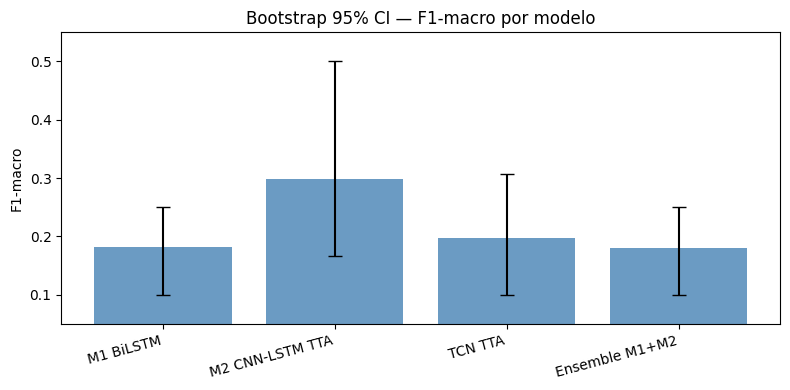

Figura guardada en results/bootstrap_ci.png


In [45]:
import numpy as np

def bootstrap_f1(y_true, y_pred, n_bootstrap=1000, seed=42, average="macro"):
    """Bootstrap CI for F1-macro (or any sklearn average)."""
    from sklearn.metrics import f1_score
    rng = np.random.default_rng(seed)
    n = len(y_true)
    scores = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        score = f1_score(y_true[idx], y_pred[idx], average=average, zero_division=0)
        scores.append(score)
    scores = np.array(scores)
    return scores.mean(), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

print("Bootstrap CI (1000 remuestras, 95%) — F1-macro\n")

# Collect all available results
bootstrap_results = {}

try:
    mu, lo, hi = bootstrap_f1(y_true_test, y_pred_test)
    bootstrap_results["M1 BiLSTM"] = (mu, lo, hi)
    print(f"  M1 BiLSTM          : {mu:.4f}  [{lo:.4f}, {hi:.4f}]")
except NameError:
    print("  M1 BiLSTM: variables not available; run its training cell first")

try:
    mu, lo, hi = bootstrap_f1(y_true_test_cnn, y_pred_cnn_tta)
    bootstrap_results["M2 CNN-LSTM TTA"] = (mu, lo, hi)
    print(f"  M2 CNN-LSTM TTA    : {mu:.4f}  [{lo:.4f}, {hi:.4f}]")
except NameError:
    print("  M2 CNN-LSTM TTA: variables not available; run its training cell first")

try:
    mu, lo, hi = bootstrap_f1(y_true_tcn, y_pred_tcn_tta)
    bootstrap_results["TCN TTA"] = (mu, lo, hi)
    print(f"  TCN TTA            : {mu:.4f}  [{lo:.4f}, {hi:.4f}]")
except NameError:
    print("  TCN TTA: variables not available; run its training cell first")

try:
    mu, lo, hi = bootstrap_f1(y_true_m1, y_pred_ensemble)
    bootstrap_results["Ensemble M1+M2"] = (mu, lo, hi)
    print(f"  Ensemble M1+M2     : {mu:.4f}  [{lo:.4f}, {hi:.4f}]")
except NameError:
    print("  Ensemble: variables not available; run its cell first")

# Bar chart with error bars
if bootstrap_results:
    import matplotlib.pyplot as plt

    labels = list(bootstrap_results.keys())
    means  = [bootstrap_results[k][0] for k in labels]
    lows   = [bootstrap_results[k][1] for k in labels]
    highs  = [bootstrap_results[k][2] for k in labels]
    errs   = [[m - l for m, l in zip(means, lows)],
              [h - m for m, h in zip(means, highs)]]

    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(labels))
    ax.bar(x, means, yerr=errs, capsize=5, color="steelblue", alpha=0.8, error_kw={"elinewidth": 1.5})
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha="right")
    ax.set_ylabel("F1-macro")
    ax.set_title("Bootstrap 95% CI — F1-macro por modelo")
    ax.set_ylim(max(0, min(lows) - 0.05), min(1.0, max(highs) + 0.05))
    plt.tight_layout()
    plt.savefig(ROOT / "results" / "bootstrap_ci.png", dpi=120)
    plt.show()
    print("Figura guardada en results/bootstrap_ci.png")


## §10b Wilcoxon test between models

§10 shows the variability within each model. This asks a different question:
comparing the two models sample by sample, are the differences systematically
positive?

The paired one-sided Wilcoxon test suits a small test set because it works on
ranks rather than on the values. Under the null hypothesis the per-sample F1
medians of M1 and M2 are equal; p > 0.05 means there is no evidence that one beats
the other.

In [46]:

from scipy.stats import wilcoxon
from sklearn.metrics import f1_score

def per_sample_correct(y_true, y_pred):
    """Per-sample hit: 1 when the prediction is correct, 0 otherwise. Used as the
    paired quantity for the test."""
    return (np.array(y_true) == np.array(y_pred)).astype(float)

wilcoxon_results = {}

def run_wilcoxon(name_a, yt_a, yp_a, name_b, yt_b, yp_b):
    """Paired Wilcoxon test between two models on the same test set."""
    if yt_a is None or yt_b is None:
        print(f"  ⚠ {name_a} o {name_b}: variables no disponibles")
        return
    if len(yt_a) != len(yt_b):
        print(f"  ⚠ {name_a} ({len(yt_a)}) y {name_b} ({len(yt_b)}) — N diferente, no comparables")
        return
    if not np.array_equal(yt_a, yt_b):
        print(f"  ⚠ {name_a} y {name_b} — labels distintos en test, no comparables")
        return

    correct_a = per_sample_correct(yt_a, yp_a)
    correct_b = per_sample_correct(yt_b, yp_b)

    if np.all(correct_a == correct_b):
        print(f"  {name_a} vs {name_b}: identical predictions, so the test does not apply")
        return

    try:
        stat, p = wilcoxon(correct_a, correct_b, alternative="two-sided", zero_method="wilcox")
        f1_a = f1_score(yt_a, yp_a, average="macro", zero_division=0)
        f1_b = f1_score(yt_b, yp_b, average="macro", zero_division=0)
        sig = "✓ p<0.05" if p < 0.05 else "✗ p>=0.05 (not significant)"
        wilcoxon_results[f"{name_a} vs {name_b}"] = {"p": p, "stat": stat, "f1_a": f1_a, "f1_b": f1_b}
        print(f"  {name_a} (F1={f1_a:.4f}) vs {name_b} (F1={f1_b:.4f}): stat={stat:.2f} p={p:.4f}  {sig}")
    except Exception as e:
        print(f"  {name_a} vs {name_b}: error — {e}")

# Determine N safely
_yt = globals().get("y_true_test")
_N = len(_yt) if _yt is not None else len(globals().get("y_true_m1", []))
print(f"=== Wilcoxon test (paired, two-sided, alpha=0.05) - N_test={_N} windows ===\n")

run_wilcoxon("M1 BiLSTM",       globals().get("y_true_test"),     globals().get("y_pred_test"),
             "M2 CNN-LSTM TTA", globals().get("y_true_test_cnn"), globals().get("y_pred_cnn_tta"))

run_wilcoxon("M1 BiLSTM",       globals().get("y_true_test"),     globals().get("y_pred_test"),
             "Ensemble M1+M2",  globals().get("y_true_m1"),       globals().get("y_pred_ensemble"))

run_wilcoxon("M1 BiLSTM",       globals().get("y_true_test"),     globals().get("y_pred_test"),
             "TCN TTA",         globals().get("y_true_tcn"),      globals().get("y_pred_tcn_tta"))

run_wilcoxon("M2 CNN-LSTM TTA", globals().get("y_true_test_cnn"), globals().get("y_pred_cnn_tta"),
             "TCN TTA",         globals().get("y_true_tcn"),      globals().get("y_pred_tcn_tta"))

print("\nNote: at this small N_test, about 30 windows, the test has low power.")
print("  p>=0.05 does NOT mean the models are equal; it means there is not enough evidence to tell them apart.")


=== Test de Wilcoxon (emparejado, bilateral, α=0.05) — N_test=13 ventanas ===

  M1 BiLSTM (F1=0.1667) vs M2 CNN-LSTM TTA (F1=0.2976): stat=0.00 p=0.5000  ✗ p≥0.05 (no significativo)
  M1 BiLSTM vs Ensemble M1+M2: predicciones idénticas — test no aplicable
  M1 BiLSTM vs TCN TTA: predicciones idénticas — test no aplicable
  M2 CNN-LSTM TTA (F1=0.2976) vs TCN TTA (F1=0.1923): stat=0.00 p=0.5000  ✗ p≥0.05 (no significativo)

Nota: con N_test pequeño (~30 ventanas), el test tiene baja potencia.
  p≥0.05 NO implica igualdad — implica evidencia insuficiente para distinguir los modelos.


## §11 Calibration

> **Single video, illustrative.** The expected calibration error here comes from a
> test set of 13 to 30 windows. Honest calibration would need the out-of-fold
> predictions from the 20-video LOVO in §8b and §A1.

A well-calibrated model has confidence close to accuracy, so its reliability curve
sits near the diagonal. The expected calibration error summarises the gap.

Models trained with focal loss tend to be overconfident, which matters as soon as
the probabilities are used for anything other than picking the top class: a
threshold, a decision rule, an abstention.

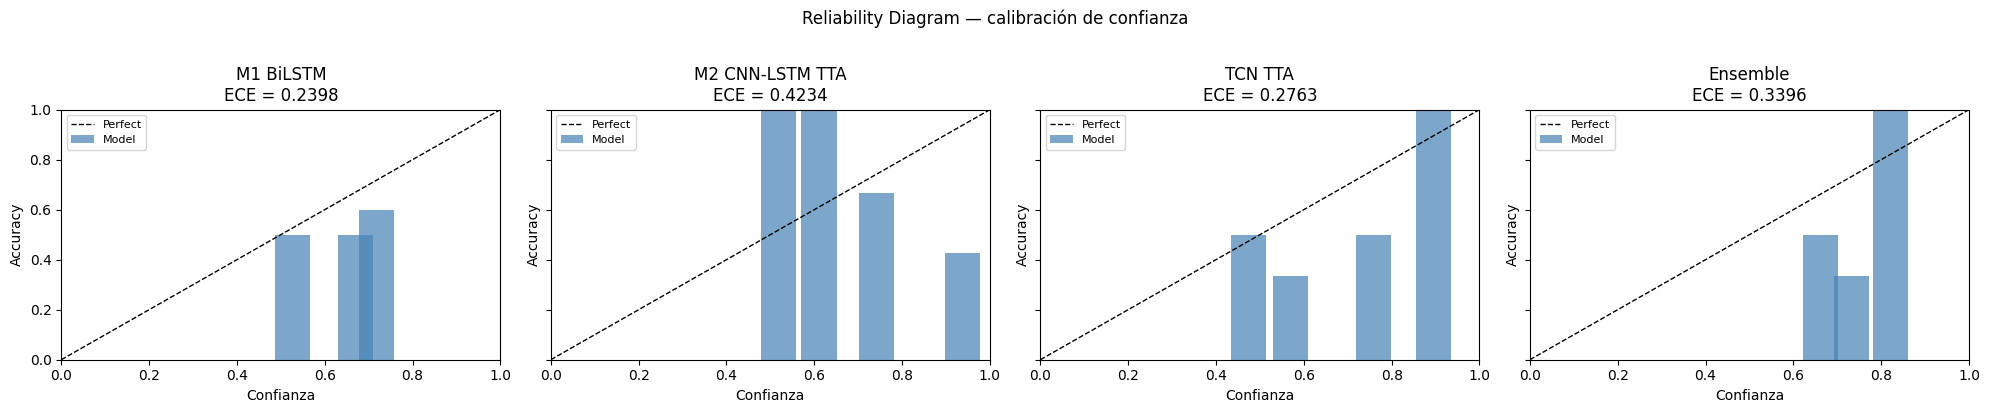

Figura guardada en results/calibration_reliability.png

ECE por modelo (más bajo = mejor calibrado):
  M1 BiLSTM           : ECE = 0.2398
  M2 CNN-LSTM TTA     : ECE = 0.4234
  TCN TTA             : ECE = 0.2763
  Ensemble            : ECE = 0.3396


In [47]:
import numpy as np
import matplotlib.pyplot as plt

def expected_calibration_error(y_true, probs, n_bins=10):
    """Compute ECE and reliability diagram data."""
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies  = predictions == y_true

    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_means_conf = []
    bin_means_acc  = []
    bin_counts     = []

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (confidences >= lo) & (confidences < hi)
        n_bin = mask.sum()
        if n_bin == 0:
            continue
        avg_conf = confidences[mask].mean()
        avg_acc  = accuracies[mask].mean()
        ece += (n_bin / len(y_true)) * abs(avg_conf - avg_acc)
        bin_means_conf.append(avg_conf)
        bin_means_acc.append(avg_acc)
        bin_counts.append(n_bin)

    return ece, bin_means_conf, bin_means_acc, bin_counts

# Build model list from available variables
calib_models = []
try:
    calib_models.append(("M1 BiLSTM",      y_true_test,     probs_m1_tta))
except NameError:
    pass
try:
    calib_models.append(("M2 CNN-LSTM TTA", y_true_test_cnn, probs_cnn_tta))
except NameError:
    pass
try:
    calib_models.append(("TCN TTA",         y_true_tcn,      probs_tcn_tta))
except NameError:
    pass
try:
    calib_models.append(("Ensemble",        y_true_m1,       probs_ensemble))
except NameError:
    pass

if not calib_models:
    print("⚠ No probabilities available; run the training cell first.")
else:
    fig, axes = plt.subplots(1, len(calib_models), figsize=(5 * len(calib_models), 4), sharey=True)
    if len(calib_models) == 1:
        axes = [axes]

    for ax, (name, y_true_c, probs_c) in zip(axes, calib_models):
        ece, bc, ba, bcount = expected_calibration_error(y_true_c, probs_c, n_bins=10)
        ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect")
        ax.bar(bc, ba, width=0.08, alpha=0.7, color="steelblue", label="Model")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_xlabel("Confianza")
        ax.set_ylabel("Accuracy")
        ax.set_title(f"{name}\nECE = {ece:.4f}")
        ax.legend(fontsize=8)

    plt.suptitle("Reliability diagram - confidence calibration", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(ROOT / "results" / "calibration_reliability.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Figura guardada en results/calibration_reliability.png")

    print("\nECE per model (lower is better calibrated):")
    for name, y_true_c, probs_c in calib_models:
        ece, _, _, _ = expected_calibration_error(y_true_c, probs_c, n_bins=10)
        print(f"  {name:20s}: ECE = {ece:.4f}")


## §12 Error analysis

> **Single video, illustrative.** This confusion matrix comes from one held-out
> video. It is a qualitative pointer, not the verdict; the cross-video error profile
> is in §8b and §A1.

Which class pairs get confused, and whether errors cluster at the start and end of
behaviour segments or spread evenly through time. The second question decides what
would help: boundary errors argue for temporal post-processing, uniform errors
argue for better features.

Analizando errores del mejor modelo: Ensemble M1+M2 TTA

Top pares de confusión (verdadero → predicho | N errores):
  approach        → sniffbody        |   2 errores
  sniffface       → sniffbody        |   1 errores
  sniffface       → approach         |   1 errores
  mount           → sniffface        |   1 errores
  mount           → sniffbody        |   1 errores
  approach        → sniffgenital     |   1 errores
  approach        → sniffface        |   1 errores


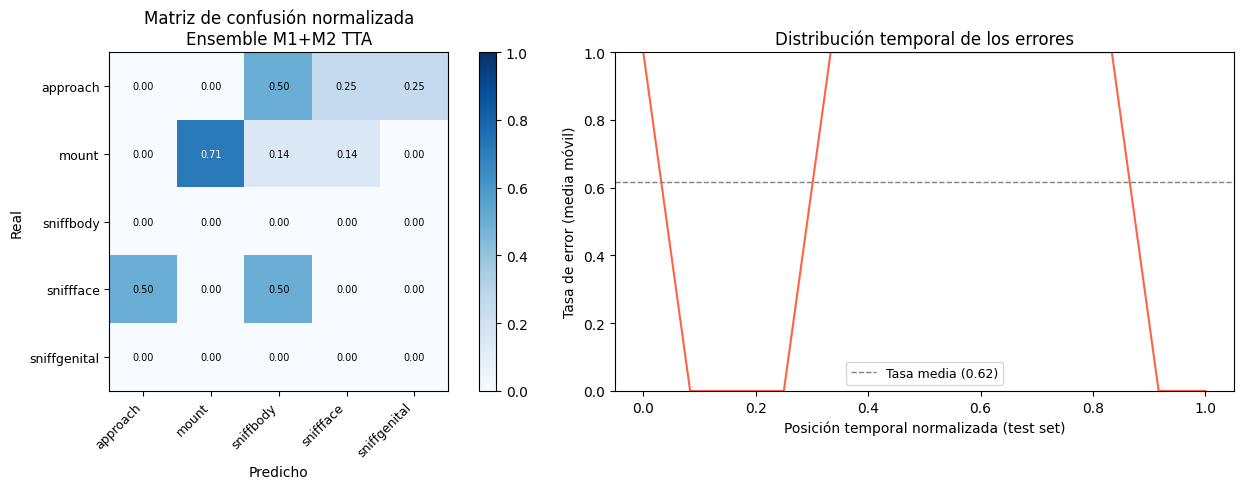

Figura guardada en results/error_analysis.png

F1 por clase con soporte (N ventanas de test):
  approach       : F1=0.000  N=  4  
  mount          : F1=0.833  N=  7  ████████████████
  sniffbody      : F1=0.000  N=  0  
  sniffface      : F1=0.000  N=  2  
  sniffgenital   : F1=0.000  N=  0  


In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ── Pick the best available model for the error analysis ───────────────────
# NOTE: the axis labels and titles in this cell stay in Spanish on purpose.
# The figure is used by the dissertation, which is not distributed here.
_pairs_to_try = [
    ("Ensemble M1+M2 TTA", globals().get("y_true_m1"),      globals().get("y_pred_ensemble")),
    ("TCN TTA",            globals().get("y_true_tcn"),      globals().get("y_pred_tcn_tta")),
    ("M2 CNN-LSTM TTA",    globals().get("y_true_test_cnn"), globals().get("y_pred_cnn_tta")),
    ("M1 BiLSTM",          globals().get("y_true_test"),     globals().get("y_pred_test")),
]
_chosen = next(((n, yt, yp) for n, yt, yp in _pairs_to_try if yt is not None and yp is not None), None)

if _chosen is None:
    print("⚠ No predictions available; run the training cells first.")
else:
    ea_name, ea_yt, ea_yp = _chosen
    class_names = enc.classes
    n_classes = len(class_names)
    label_ids = list(range(n_classes))
    print(f"Analysing the errors of the best model: {ea_name}\n")

    # ── 1. The most frequent confusion pairs ────────────────────────────────
    cm = confusion_matrix(ea_yt, ea_yp, labels=label_ids)
    np.fill_diagonal(cm, 0)  # eliminar diagonal (aciertos)

    error_pairs = []
    for i in range(n_classes):
        for j in range(n_classes):
            if cm[i, j] > 0:
                error_pairs.append((cm[i, j], class_names[i], class_names[j]))
    error_pairs.sort(reverse=True)

    print("Top confusion pairs (true -> predicted | N errors):")
    for count, true_cls, pred_cls in error_pairs[:10]:
        print(f"  {true_cls:15s} → {pred_cls:15s}  | {count:3d} errores")

    # ── 2. Heatmap de errores ───────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm_norm = confusion_matrix(ea_yt, ea_yp, labels=label_ids, normalize="true")
    im = axes[0].imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    axes[0].set_xticks(range(n_classes))
    axes[0].set_yticks(range(n_classes))
    axes[0].set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
    axes[0].set_yticklabels(class_names, fontsize=9)
    axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real")
    axes[0].set_title(f"Matriz de confusión normalizada\n{ea_name}")
    for i in range(n_classes):
        for j in range(n_classes):
            axes[0].text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center",
                         fontsize=7, color="white" if cm_norm[i,j] > 0.5 else "black")
    plt.colorbar(im, ax=axes[0])

    # ── 3. Temporal distribution of the errors ──────────────────────────────
    n_test = len(ea_yt)
    temporal_pos = np.arange(n_test) / max(n_test - 1, 1)
    is_error = (ea_yt != ea_yp).astype(int)

    window_t = max(1, n_test // 20)
    error_rate_smooth = np.convolve(is_error, np.ones(window_t) / window_t, mode="same")

    axes[1].plot(temporal_pos, error_rate_smooth, color="tomato", linewidth=1.5)
    axes[1].axhline(is_error.mean(), color="gray", linestyle="--", linewidth=1,
                    label=f"Tasa media ({is_error.mean():.2f})")
    axes[1].set_xlabel("Posición temporal normalizada (test set)")
    axes[1].set_ylabel("Tasa de error (media móvil)")
    axes[1].set_title("Distribución temporal de los errores")
    axes[1].legend(fontsize=9)
    axes[1].set_ylim(0, 1)

    plt.tight_layout()
    plt.savefig(ROOT / "results" / "error_analysis.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Figura guardada en results/error_analysis.png")

    # ── 4. Per-class F1, with the sample count ──────────────────────────────
    from sklearn.metrics import classification_report
    # Pass labels= to force all classes to appear even if absent from predictions
    report = classification_report(ea_yt, ea_yp,
                                   labels=label_ids,
                                   target_names=class_names,
                                   zero_division=0, output_dict=True)
    print("\nPer-class F1 with support (N test windows):")
    for cls in class_names:
        if cls in report:
            f1 = report[cls]["f1-score"]
            sup = int(report[cls]["support"])
            bar = "█" * int(f1 * 20)
            print(f"  {cls:15s}: F1={f1:.3f}  N={sup:3d}  {bar}")


## Phase 4 conclusions

**These conclusions were written before the honest evaluation and two of them did
not survive it.** They are kept because the sequence matters: this is what the
single-video, leaky-cross-validation protocol appeared to show. §A1 and §A3 below,
and notebook 05, contain the corrections.

| Step | What phase 4 concluded | Status after §A1 and §A3 |
|---|---|---|
| B1 to B2 | Skeleton correction improves macro-F1 (+5.5 pp) | **Refuted.** Under paired LOVO over 20 videos the correction significantly *hurts*: Δ`f1_event` = -0.018, p = 0.002 |
| B2 to B3 | Δz adds little | Holds, though Δz is the largest single jump in the deep single-video ablation |
| B3 to B4 | Relational features improve the sniff variants | Holds. This and Δz are where the robust gain comes from |
| B4 vs M1 | BiLSTM clearly beats the random forest | **Refuted.** It compared leaky CV against a single-video hold-out. Under one protocol the four models tie at 0.53 to 0.58 `f1_event` |
| M1 vs M2 | BiLSTM at least matches CNN-LSTM | Holds |
| M1 vs M4 | TCN similar or slightly below | Holds |
| Smoothing | Depends on the test set | Holds |
| Ensemble | M1+M2 does not improve on M1 alone | Holds. The models make correlated errors |

**What survived.** Feature engineering helps, and the help comes from Δz and the
relational features rather than from the skeleton correction. Architecture choice
is not decisive at this data scale. Both of those hold under the honest protocol.

**What the regime explains.** With about 208 windows of 64 frames over five
unbalanced classes, model capacity exceeds the available signal. Differences of
0.02 to 0.05 in F1 cannot be read without the intervals in §10 and the p-values in
§10b, and reading them anyway is how the two refuted rows got written.

**Where it went next.** Scaling the evaluation to 20 videos (§A1), then to nine
laboratories (notebook 07), and active learning in notebook 06.

## §A1 Honest LOVO benchmark: shallow models, 20 videos, raw tracking

Replaces the leaky cross-validation of §4 with **leave-one-video-out** over the
20-video cache (7,134 windows), using the same label space and the same metrics as
the deep models in notebook 05, so the two are finally comparable.

Three numbers are reported per fold:

- `f1_eval`: macro over the **5 classes present in at least 2 videos** (attack,
  mount, sniff, sniffface, sniffgenital). Restricting to these is what makes a
  cross-video comparison meaningful; a class that appears in one video cannot be
  evaluated across videos at all.
- `f1_full`: macro over all 8 classes in the cache, deflated by the classes that are
  absent from most folds.
- `f1_event`: the **official MABe metric**, an interval F-beta.

**The headline uses raw tracking**, because the correction was shown to hurt the
classifier. The paired-LOVO cell below reproduces that here rather than asking you to
take it on trust; it writes `results/skeleton_effect_baseline.csv`.

In [49]:
import sys, pathlib
_r = pathlib.Path.cwd()
while _r != _r.parent and not (_r/'src').exists(): _r = _r.parent
sys.path.insert(0, str(_r)) if str(_r) not in sys.path else None

import numpy as np, pandas as pd
from sklearn.model_selection import LeaveOneGroupOut
from src.evaluation.lovo import (
    load_event_cache, evaluable_class_ids, fold_metrics, run_tree, event_f1_for_fold)

# Honest 20-video protocol, using the OFFICIAL MABe metric (f1_event, an interval
# metric) alongside the per-window F1-macro. The headline uses RAW tracking: the harness
# showed that the MouseSkeleton correction hurts the classifier, so the reportable
# figure uses raw features. The cache carries per-window metadata (agent, target,
# [start, stop) frames) that the interval metric needs.
FEAT  = _r / "dataset" / "features"
CACHE = FEAT / "CalMS21_task1_multi_20_event_raw.npz"   # raw, 20 videos, 7134 windows
X, y, vids, classes, ev = load_event_cache(CACHE)
nC = len(classes); eids = evaluable_class_ids(y, vids, classes)
print(f"Cache: {CACHE.name}  |  windows={len(X)}  videos={len(set(vids))}")
print("Classes evaluable across videos:", [classes[c] for c in eids])
if ev is None:
    print("⚠ event cache has no per-window metadata; run the cache-building cell in 03_features")

RESULTS_DIR = globals().get("RESULTS_DIR", _r / "results")
LAB = "CalMS21_task1"
rows = []
for name in ["rf", "histgb"]:
    for fi, (tr, te) in enumerate(LeaveOneGroupOut().split(X, y, groups=vids)):
        pred, _ = run_tree(name, X[tr], y[tr], X[te])
        _, _, fe, ff = fold_metrics(y[te], pred, nC, eids)
        row = {"model": name, "fold": fi, "test_video": vids[te][0],
               "f1_eval": round(fe, 4), "f1_full": round(ff, 4)}
        if ev is not None:
            fev = event_f1_for_fold(LAB, vids[te][0], te, pred, classes, vids, ev)
            row["f1_event"] = round(fev, 4) if not np.isnan(fev) else np.nan
        rows.append(row)
df_lovo_tree = pd.DataFrame(rows)
_cols = ["f1_eval", "f1_full"] + (["f1_event"] if "f1_event" in df_lovo_tree else [])
_summary = df_lovo_tree.groupby("model")[_cols].agg(["mean", "std"]).round(4)
print(_summary.to_string())
df_lovo_tree.to_csv(RESULTS_DIR / "lovo_tree_event.csv", index=False)
print("Saved:", RESULTS_DIR / "lovo_tree_event.csv")
_summary

Caché: CalMS21_task1_multi_20_event_raw.npz  |  ventanas=7134  vídeos=20
Clases evaluables cross-vídeo: ['attack', 'mount', 'sniff', 'sniffface', 'sniffgenital']
       f1_eval         f1_full         f1_event        
          mean     std    mean     std     mean     std
model                                                  
histgb  0.7026  0.1762  0.4419  0.1503   0.5795  0.1552
rf      0.6451  0.2143  0.3962  0.1450   0.5331  0.1831
Guardado: ..\results\lovo_tree_event.csv


f1_eval         f1_full         f1_event        
          mean     std    mean     std     mean     std
model                                                  
histgb  0.7026  0.1762  0.4419  0.1503   0.5795  0.1552
rf      0.6451  0.2143  0.3962  0.1450   0.5331  0.1831

## §A3 Does the skeleton correction help? Paired LOVO, 20 videos

Runs the same honest benchmark on **corrected** and on **raw** features, using
caches that are identical in videos, windows and labels and differ only in whether
`smooth_video` ran: `CalMS21_task1_multi_20_event.npz` against `..._event_raw.npz`.

Pairing is what gives this power. With 20 videos there are up to 40
`(model, video)` pairs, 2 models by 20 folds, and 5 cross-video evaluable classes
instead of the 3 available with 5 videos. The paired delta, corrected minus raw,
with a Wilcoxon test and bootstrap intervals, is therefore a real test rather than
a direction.

The expected result is a negative, significant delta, which is what the harness
found.

In [1]:
# ── Effect of the MouseSkeleton correction (classical models, paired LOVO) ───
# Honest 20-video protocol: 7134 windows, 5 classes evaluable across videos.
# The two caches are identical in videos, windows and labels, and differ only in the
# correction: CalMS21_task1_multi_20_event.npz against ..._event_raw.npz.
import sys, pathlib
_r = pathlib.Path.cwd()
while _r != _r.parent and not (_r/'src').exists(): _r = _r.parent
sys.path.insert(0, str(_r)) if str(_r) not in sys.path else None

import numpy as np, pandas as pd
from sklearn.model_selection import LeaveOneGroupOut
from src.evaluation.lovo import (
    load_event_cache, evaluable_class_ids, fold_metrics, run_tree, event_f1_for_fold)
from src.skeleton.metrics import bootstrap_ci, paired_wilcoxon

RESULTS_DIR = globals().get("RESULTS_DIR", _r / "results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
LAB  = "CalMS21_task1"
FEAT = _r / "dataset" / "features"
CACHES = {"corrected": FEAT / "CalMS21_task1_multi_20_event.npz",
          "raw":       FEAT / "CalMS21_task1_multi_20_event_raw.npz"}
TREE_MODELS = ["rf", "histgb"]

for _tag, _p in CACHES.items():
    if not _p.exists():
        raise FileNotFoundError(
            f"Cache {_tag} is missing: {_p.name}. Build the 20-video caches with "
            "the cache-building cell in 03_features (RECOMPUTE=True).")

def _lovo_tree(cache_path):
    """RF/HistGB under LOVO over one cache -> one row per (model, video)."""
    X, y, vids, classes, ev = load_event_cache(cache_path)
    nC = len(classes); eids = evaluable_class_ids(y, vids, classes)
    rows = []
    for name in TREE_MODELS:
        for tr, te in LeaveOneGroupOut().split(X, y, groups=vids):
            pred, _ = run_tree(name, X[tr], y[tr], X[te])
            _, _, fe, ff = fold_metrics(y[te], pred, nC, eids)
            row = {"model": name, "test_video": vids[te][0],
                   "f1_eval": round(fe, 4), "f1_full": round(ff, 4)}
            if ev is not None:
                fev = event_f1_for_fold(LAB, vids[te][0], te, pred, classes, vids, ev)
                row["f1_event"] = round(fev, 4) if not np.isnan(fev) else np.nan
            rows.append(row)
    return pd.DataFrame(rows)

df_corr_cls = _lovo_tree(CACHES["corrected"])
df_raw_cls  = _lovo_tree(CACHES["raw"])

_metrics = [m for m in ("f1_eval", "f1_full", "f1_event") if m in df_corr_cls.columns]
_agg = (df_corr_cls.groupby("model")[_metrics].mean().round(4)
        .join(df_raw_cls.groupby("model")[_metrics].mean().round(4),
              lsuffix="_corr", rsuffix="_raw"))
print("=== RF/HistGB LOVO - mean over 20 folds (corrected vs raw) ===")
print(_agg.to_string())

# Paired delta (corrected minus raw) per (model, video), up to 2 x 20 = 40 pairs
_KEY = ["model", "test_video"]
_verdict = []
for metric in _metrics:
    m = (df_raw_cls[_KEY + [metric]].merge(df_corr_cls[_KEY + [metric]], on=_KEY,
                                           suffixes=("_raw", "_corr"))
         .dropna(subset=[f"{metric}_raw", f"{metric}_corr"]))
    if len(m) < 3:
        continue
    raw_v = m[f"{metric}_raw"].to_numpy(); corr_v = m[f"{metric}_corr"].to_numpy()
    delta = corr_v - raw_v
    lo, hi = bootstrap_ci(delta, statistic="mean")
    wil = paired_wilcoxon(raw_v, corr_v)
    _verdict.append({
        "metric": metric, "n_pairs": len(m),
        "raw_mean": round(float(raw_v.mean()), 4),
        "corr_mean": round(float(corr_v.mean()), 4),
        "delta_mean": round(float(delta.mean()), 4),
        "ci_lo": round(float(lo), 4), "ci_hi": round(float(hi), 4),
        "wilcoxon_p": round(float(wil["p_value"]), 4),
        "helps": bool(delta.mean() > 0 and (lo > 0 or hi < 0) and wil["significant"]),
    })
df_skeleton_effect_cls = pd.DataFrame(_verdict)
print("\n=== MouseSkeleton effect (corrected minus raw), classical models, 20 videos ===")
print(df_skeleton_effect_cls.to_string(index=False))
df_skeleton_effect_cls.to_csv(RESULTS_DIR / "skeleton_effect_baseline.csv", index=False)
print("\nGuardado:", RESULTS_DIR / "skeleton_effect_baseline.csv")
print("With about 40 pairs (2 models x 20 folds) the test has real power; expect "
      "delta negativo y significativo (cf. results/skeleton_effect_3way.csv, trees p≈0.002).")

=== RF/HistGB LOVO — media sobre 20 folds (corregido vs crudo) ===
        f1_eval_corr  f1_full_corr  f1_event_corr  f1_eval_raw  f1_full_raw  f1_event_raw
model                                                                                    
histgb        0.6584        0.3828         0.5566       0.7026       0.4419        0.5795
rf            0.6240        0.3667         0.5210       0.6451       0.3962        0.5331

=== Efecto MouseSkeleton (corregido − crudo), clásicos · 20 vídeos ===
  metric  n_pairs  raw_mean  corr_mean  delta_mean   ci_lo   ci_hi  wilcoxon_p  ayuda
 f1_eval       40    0.6739     0.6412     -0.0326 -0.0494 -0.0170      0.0003  False
 f1_full       40    0.4190     0.3747     -0.0443 -0.0708 -0.0198      0.0006  False
f1_event       40    0.5563     0.5388     -0.0175 -0.0280 -0.0070      0.0019  False

Guardado: c:\Users\User\dev\tfm\results\skeleton_effect_baseline.csv
Con ~40 pares (2 modelos × 20 folds) el test tiene potencia real; se espera delta negat